In [ ]:
# ==========================
# Cell 1 — Importss
# ==========================
# If running in Google Colab, uncomment:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    pass

import os
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, ParameterGrid
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

# CatBoost is optional
try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
except Exception:
    CATBOOST_AVAILABLE = False

print("CatBoost available:", CATBOOST_AVAILABLE)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CatBoost available: False


In [ ]:

# ==========================
# Cell 2 — Settings (your source of truth + modes)
# ==========================

# --- Paths (your logic) ---
CSV_PATH_LOCAL = "/mnt/data/engineered_metadata.csv"
CSV_PATH_DRIVE = "/content/drive/MyDrive/BCU/THESIS/datasets/engineered_metadata.csv"
CSV_PATH = CSV_PATH_LOCAL if os.path.exists(CSV_PATH_LOCAL) else CSV_PATH_DRIVE

# --- Core dataset config ---
GROUP_COL = "battery_id"
TARGET = "cycle_duration"
FEATURES = [
    'avg_voltage', 'voltage_drop', 'voltage_gradient', 'voltage_std',
    'avg_current', 'max_current', 'current_std',
    'initial_temp', 'final_temp', 'temp_rise',
    'energy_approx', 'start_voltage', 'end_voltage'
]

TEST_BATTERY_FRAC = 0.25
USE_IQR_CLEANING = True
IQR_APPLY_TO_TEST = True
N_GROUP_CV_SPLITS = 5

# --- Conformal / buffer ---
ROBUST_ALPHAS = [0.05, 0.10, 0.20]
ROBUST_BUFFER_MODES = ["none", "fixed"]  # none vs q-quantile buffer

# --- Controller horizons & budgets ---
NIGHTS_H = [0.75, 1.0, 1.5]
BUDGETS = [2.0, 5.0, 10.0]
BUDGETS_EXT = sorted(set([1.0] + BUDGETS))

# --- Floors ---
PHASE_FLOORS = {"active": 70.0, "quiet": 30.0, "predawn": 50.0}
PHASE_SPLIT  = {"active": 0.4,  "quiet": 0.4,  "predawn": 0.2}
PRIORITY = ("active", "predawn", "quiet")

# --- MPC-style plug-in baseline ---
PHASE_WEIGHTS = {"active": 3.0, "predawn": 2.0, "quiet": 1.0}
MPC_POLICY_NAME = "MPC-style baseline"

# --- Actuation realism ---
HYSTERESIS = 5.0
RAMP_LIMIT = 10.0

# --- Fixed safety scan ---
S_MIN, S_MAX = 0.20, 1.20
S_GRID = np.linspace(S_MIN, S_MAX, 201)

# --- Adaptive ---
ADAPT_WINDOW = 200
ADAPT_KP     = 0.6
SAFETY_INIT  = 0.85

PART_NIGHT_SCHEDULE = {"active": 100.0, "quiet": 50.0, "predawn": 70.0}

# --- Modes ---
MODE = "review_fast"  # light | medium | heavy

MODES = {
    "light":  {"split_seeds": [0, 1],               "model_seeds": [42],     "rf_grid": "tiny",  "run_catboost": False},
    "review_fast":  {"split_seeds": [0, 1, 2, 3, 4],      "model_seeds": [0,1],  "rf_grid": "small",  "run_catboost": False},
    "medium": {"split_seeds": [0, 1, 2, 3, 4],      "model_seeds": [42],     "rf_grid": "small", "run_catboost": True},
    "heavy_lite":  {"split_seeds": [0, 1, 2, 3, 4],      "model_seeds": [0,1,2],  "rf_grid": "small",  "run_catboost": False},
    "heavy":  {"split_seeds": list(range(10)),      "model_seeds": [0,1,2],  "rf_grid": "full",  "run_catboost": True},
}

CFG = MODES[MODE]

# --- RF grids by mode ---
RF_GRIDS = {
    "tiny": {
        "n_estimators": [400],
        "max_depth": [None],
        "min_samples_leaf": [2],
        "max_features": ["sqrt"],
    },
    "small": {
        "n_estimators": [400, 800],
        "max_depth": [None, 20],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", 0.5],
    },
    "full": {
        "n_estimators": [400, 800, 1200],
        "max_depth": [None, 20, 30],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", 0.5],
    },
}

# --- Generalization protocols ---
#PROTOCOLS = ["standard", "aging_shift"]
PROTOCOLS = ["standard"]

# aging-shift parameters (tweak as you like)
SHIFT_EARLY_FRAC = 0.60   # train on first 60% of cycles per battery
SHIFT_LATE_FRAC  = 0.30   # test on last 30% of cycles per battery
SHIFT_MIN_CYCLES = 10     # drop batteries with too few cycles (optional but recommended)
SHIFT_ORDER_COL  = "uid"  # your within-battery ordering column

print("MODE:", MODE)
print("CSV:", CSV_PATH)
print("Splits:", CFG["split_seeds"], "| Model seeds:", CFG["model_seeds"])
print("RF grid mode:", CFG["rf_grid"], "| CatBoost:", CFG["run_catboost"])

MODE: review_fast
CSV: /content/drive/MyDrive/BCU/THESIS/datasets/engineered_metadata.csv
Splits: [0, 1, 2, 3, 4] | Model seeds: [0, 1]
RF grid mode: small | CatBoost: False


In [ ]:
# ==========================
# Cell 3 — Load + Prepare Data (df0)
# ==========================

df_raw = pd.read_csv(CSV_PATH)
print("Raw:", df_raw.shape)

# required columns check
need_cols = ["uid", GROUP_COL, TARGET]
for c in need_cols:
    assert c in df_raw.columns, f"Missing required column: {c}"
for c in FEATURES:
    assert c in df_raw.columns, f"Missing feature column: {c}"

# keep discharge only if column exists
df0 = df_raw.copy()
if "type" in df0.columns:
    df0 = df0[df0["type"].astype(str).str.lower().eq("discharge")].copy()

# coerce numeric
df0[GROUP_COL] = df0[GROUP_COL].astype(str)
df0["uid"] = pd.to_numeric(df0["uid"], errors="coerce")
df0[TARGET] = pd.to_numeric(df0[TARGET], errors="coerce")
for f in FEATURES:
    df0[f] = pd.to_numeric(df0[f], errors="coerce")

# drop missing
df0 = df0.dropna(subset=[GROUP_COL, "uid", TARGET] + FEATURES).copy()

# sort (important for any time-aware logic later)
df0 = df0.sort_values([GROUP_COL, "uid"]).reset_index(drop=True)

print("Prepared df0:", df0.shape, "| batteries:", df0[GROUP_COL].nunique())
print("Target mean:", round(df0[TARGET].mean(), 3), "| std:", round(df0[TARGET].std(), 3))

Raw: (7565, 31)
Prepared df0: (2794, 31) | batteries: 34
Target mean: 3218.72 | std: 1389.093


In [ ]:
# ==========================
# Cell 4 — Group-safe split (battery-level) + optional IQR cleaning
# ==========================
def add_age_fraction(df, group_col=GROUP_COL, order_col="uid"):
    """
    Adds _age_frac in [0,1] based on within-battery rank of order_col.
    Assumes df is already sorted by [group_col, order_col] (you do this).
    """
    out = df.copy()
    # rank starting at 0
    out["_age_rank"] = out.groupby(group_col)[order_col].rank(method="first") - 1
    out["_age_n"]    = out.groupby(group_col)[order_col].transform("count")
    out["_age_frac"] = out["_age_rank"] / np.maximum(1.0, (out["_age_n"] - 1.0))
    return out


def make_split(
    df0,
    split_seed,
    use_iqr=USE_IQR_CLEANING,
    protocol="standard",
    early_frac=SHIFT_EARLY_FRAC,
    late_frac=SHIFT_LATE_FRAC,
    min_cycles=SHIFT_MIN_CYCLES,
    order_col=SHIFT_ORDER_COL
):
    gss = GroupShuffleSplit(n_splits=1, test_size=TEST_BATTERY_FRAC, random_state=split_seed)
    tr_idx, te_idx = next(gss.split(df0, groups=df0[GROUP_COL]))

    df_train = df0.iloc[tr_idx].copy().reset_index(drop=True)
    df_test  = df0.iloc[te_idx].copy().reset_index(drop=True)

    # leakage check
    assert set(df_train[GROUP_COL]).isdisjoint(set(df_test[GROUP_COL])), "Leakage: shared batteries!"

    # ---- aging-shift filter (train early, test late) ----
    if protocol == "aging_shift":
        df_train = add_age_fraction(df_train, group_col=GROUP_COL, order_col=order_col)
        df_test  = add_age_fraction(df_test,  group_col=GROUP_COL, order_col=order_col)

        # optionally remove very short batteries (stabilizes the filter)
        df_train = df_train[df_train["_age_n"] >= min_cycles].copy()
        df_test  = df_test[df_test["_age_n"] >= min_cycles].copy()

        # early part for training, late part for testing
        df_train = df_train[df_train["_age_frac"] <= early_frac].copy()
        df_test  = df_test[df_test["_age_frac"] >= (1.0 - late_frac)].copy()

        # drop helper cols
        df_train = df_train.drop(columns=["_age_rank","_age_n","_age_frac"])
        df_test  = df_test.drop(columns=["_age_rank","_age_n","_age_frac"])

    # ---- optional IQR cleaning (fit bounds on *filtered* train) ----
    if use_iqr:
        q1 = df_train[TARGET].quantile(0.25)
        q3 = df_train[TARGET].quantile(0.75)
        iqr = max(0.0, q3 - q1)

        lb = max(0.0, q1 - 1.5 * iqr)
        ub = max(lb, q3 + 1.5 * iqr)   # ensure ub >= lb



        before_tr, before_te = len(df_train), len(df_test)
        df_train = df_train[df_train[TARGET].between(lb, ub)].copy().reset_index(drop=True)
        if IQR_APPLY_TO_TEST:
            df_test = df_test[df_test[TARGET].between(lb, ub)].copy().reset_index(drop=True)

        print(f"[{protocol} | split {split_seed}] IQR bounds: [{lb:.3f}, {ub:.3f}] | "
              f"train {len(df_train)}/{before_tr} | test {len(df_test)}/{before_te}")

    return df_train.reset_index(drop=True), df_test.reset_index(drop=True)


# quick test run (light sanity)
df_train, df_test = make_split(df0, split_seed=CFG["split_seeds"][0], use_iqr=USE_IQR_CLEANING)
print("Train batteries:", df_train[GROUP_COL].nunique(), "| Test batteries:", df_test[GROUP_COL].nunique())
print("Train rows:", len(df_train), "| Test rows:", len(df_test))

[standard | split 0] IQR bounds: [1697.546, 4308.298] | train 1475/2140 | test 351/654
Train batteries: 20 | Test batteries: 9
Train rows: 1475 | Test rows: 351


In [ ]:
# ==========================
# Cell 5 — Model fit (group-safe) + OOF residuals (train only)
# Supports: RandomForest ("rf") + optional CatBoost ("cat")
# ==========================

def fit_predict(df_train, df_test, model_name="rf", model_seed=42):
    X_train = df_train[FEATURES].to_numpy()
    y_train = df_train[TARGET].to_numpy().astype(float)
    g_train = df_train[GROUP_COL].to_numpy()

    X_test  = df_test[FEATURES].to_numpy()
    y_test  = df_test[TARGET].to_numpy().astype(float)

    # group-safe CV
    n_groups = len(np.unique(g_train))
    n_splits = min(N_GROUP_CV_SPLITS, n_groups)
    gkf = GroupKFold(n_splits=n_splits)

    # ----------------------
    # Model: RandomForest
    # ----------------------
    if model_name == "rf":
        grid = RF_GRIDS[CFG["rf_grid"]]
        best_mae = None
        best_params = None

        for params in ParameterGrid(grid):
            maes = []
            for tr, va in gkf.split(X_train, y_train, g_train):
                m = RandomForestRegressor(random_state=model_seed, n_jobs=-1, **params)
                m.fit(X_train[tr], y_train[tr])
                pred = m.predict(X_train[va])
                maes.append(mean_absolute_error(y_train[va], pred))
            avg = float(np.mean(maes))
            if best_mae is None or avg < best_mae:
                best_mae = avg
                best_params = params

        # OOF
        oof = np.zeros_like(y_train, dtype=float)
        for tr, va in gkf.split(X_train, y_train, g_train):
            m = RandomForestRegressor(random_state=model_seed, n_jobs=-1, **best_params)
            m.fit(X_train[tr], y_train[tr])
            oof[va] = m.predict(X_train[va])

        resid = np.abs(y_train - oof)

        # final fit + test pred
        final = RandomForestRegressor(random_state=model_seed, n_jobs=-1, **best_params)
        final.fit(X_train, y_train)
        y_hat = final.predict(X_test).astype(float)

        return {
            "model": "rf",
            "best_params": best_params,
            "cv_mae": float(best_mae),
            "y_train": y_train,
            "oof": oof,
            "resid": resid,
            "y_true": y_test,
            "y_hat": y_hat,
        }

    # ----------------------
    # Model: CatBoost (optional)
    # ----------------------
    if model_name == "cat":
        assert CATBOOST_AVAILABLE, "CatBoost not installed/available in this environment."

        # Simple grid (keep small first; expand in heavy mode later)
        # CatBoost handles nonlinearity well; we keep it light and stable.
        cat_grid = [
            {"depth": 6, "learning_rate": 0.1, "iterations": 1000},
            {"depth": 8, "learning_rate": 0.05, "iterations": 2000},
        ]

        best_mae = None
        best_params = None

        for params in cat_grid:
            maes = []
            for tr, va in gkf.split(X_train, y_train, g_train):
                m = CatBoostRegressor(
                    random_seed=model_seed,
                    loss_function="MAE",
                    verbose=False,
                    **params
                )
                m.fit(X_train[tr], y_train[tr])
                pred = m.predict(X_train[va])
                maes.append(mean_absolute_error(y_train[va], pred))
            avg = float(np.mean(maes))
            if best_mae is None or avg < best_mae:
                best_mae = avg
                best_params = params

        # OOF
        oof = np.zeros_like(y_train, dtype=float)
        for tr, va in gkf.split(X_train, y_train, g_train):
            m = CatBoostRegressor(
                random_seed=model_seed,
                loss_function="MAE",
                verbose=False,
                **best_params
            )
            m.fit(X_train[tr], y_train[tr])
            oof[va] = m.predict(X_train[va])

        resid = np.abs(y_train - oof)

        # final fit + test pred
        final = CatBoostRegressor(
            random_seed=model_seed,
            loss_function="MAE",
            verbose=False,
            **best_params
        )
        final.fit(X_train, y_train)
        y_hat = final.predict(X_test)

        return {
            "model": "cat",
            "best_params": best_params,
            "cv_mae": float(best_mae),
            "y_train": y_train,
            "oof": oof,
            "resid": resid,
            "y_true": y_test,
            "y_hat": np.array(y_hat, dtype=float),
        }

    raise ValueError("model_name must be 'rf' or 'cat'")


# quick test run on current split
art = fit_predict(df_train, df_test, model_name="rf", model_seed=CFG["model_seeds"][0])
print("Model:", art["model"], "| CV MAE:", round(art["cv_mae"], 3), "| resid q80:", round(np.quantile(art["resid"], 0.8), 3))
print("Test MAE:", round(mean_absolute_error(art["y_true"], art["y_hat"]), 3))

Model: rf | CV MAE: 103.431 | resid q80: 135.477
Test MAE: 117.675


In [ ]:
# ==========================
# Cell 6B — Controllers + Metrics (same logic as old notebook)
# ==========================

from collections import deque
import numpy as np
from collections import deque


def rolling_conformal_q(err, alpha=0.1, W=200, q_init=None, smooth=0.9):
    """
    err = (y_hat - y_true). Positive means overestimation.
    Returns q_t such that y_lower = y_hat - q_t is conservative.
    Uses only past errors.
    """
    if q_init is None:
        q_init = np.quantile(err, 1 - alpha)

    buf = deque(maxlen=W)
    q = q_init
    q_series = np.zeros_like(err, dtype=float)

    for t in range(len(err)):
        if len(buf) >= max(20, W//5):
            q_raw = float(np.quantile(np.array(buf), 1 - alpha))
            q = smooth*q + (1 - smooth)*q_raw
        q_series[t] = q
        buf.append(float(err[t]))

    return q_series


def time_weighted_floor(floors, split):
    return (split['active']*floors['active'] +
            split['quiet'] *floors['quiet']  +
            split['predawn']*floors['predawn'])


def ml_pct_from_forecast(y_hat, T, safety, qbuf, floors, split):
    # conservative runtime (forecast minus buffer)
    safe_runtime = np.maximum(0.0, y_hat - qbuf)
    pct_raw = 100.0 * safety * (safe_runtime / T)
    floor_avg = time_weighted_floor(floors, split)
    return np.clip(pct_raw, floor_avg, 100.0)


def apply_hysteresis_and_ramp(pct, hysteresis=HYSTERESIS, ramp=RAMP_LIMIT):
    pct = np.asarray(pct, dtype=float).copy()
    if len(pct) == 0:
        return pct

    out = np.zeros_like(pct)
    out[0] = pct[0]

    for i in range(1, len(pct)):
        desired = pct[i]
        prev = out[i-1]

        # hysteresis deadband
        if abs(desired - prev) <= hysteresis:
            out[i] = prev
            continue

        # ramp limit
        delta = desired - prev
        delta = np.clip(delta, -ramp, ramp)
        out[i] = prev + delta

    return out


def avg_to_phase_arrays(pct_avg, floors, split, priority=PRIORITY):
    """
    Convert avg brightness pct_avg into per-phase arrays (active/quiet/predawn),
    keeping floors, and allocating any remaining budget by priority.
    """
    pct_avg = np.asarray(pct_avg, dtype=float)
    n = len(pct_avg)

    # floors per phase
    pct_phase = {k: np.full(n, float(floors[k]), dtype=float) for k in floors}
    floor_avg = time_weighted_floor(floors, split)

    rem = np.maximum(0.0, pct_avg - floor_avg)

    # allocate remainder to the first phase in priority order
    for k in priority:
        if split[k] <= 0:
            continue
        add = rem / split[k]
        pct_phase[k] += add
        rem = np.zeros_like(rem)
        break

    pct_eff = np.zeros(n, dtype=float)
    for k in floors:
        pct_eff += pct_phase[k] * float(split[k])

    detail = {"floor_avg": float(floor_avg)}
    return pct_phase["active"], pct_phase["quiet"], pct_phase["predawn"], pct_eff, detail

def simulate_metrics_phase(phase_arrays, T, y_true, split, phase_order=None):
    """
    Phase-aware evaluator.

    phase_arrays : dict
        Example:
        {
            "active":  np.array([...], dtype=float),
            "quiet":   np.array([...], dtype=float),
            "predawn": np.array([...], dtype=float),
        }

    T : float
        Total horizon duration in seconds.

    y_true : array-like
        True runtime at 100% brightness, in seconds.

    split : dict
        Phase fractions over the total horizon.

    phase_order : list or None
        Temporal order of phases. If None, uses ["active", "quiet", "predawn"]
        filtered by availability.

    Returns:
        metrics dict with same keys as your old evaluator.
    """
    y_true = np.asarray(y_true, dtype=float)
    n = len(y_true)

    if phase_order is None:
        phase_order = [p for p in ["active", "quiet", "predawn"] if p in phase_arrays]

    unmet_minutes = np.zeros(n, dtype=float)
    blackout = np.zeros(n, dtype=bool)
    commanded_demand = np.zeros(n, dtype=float)  # in "100%-seconds"

    for t in range(n):
        remaining_budget_true = float(y_true[t])

        elapsed_real_time = 0.0
        cumulative_demand = 0.0
        depleted = False

        # total commanded demand over full schedule (used for ES, same semantics as before)
        total_demand_t = 0.0

        for p in phase_order:
            d_p = float(T) * float(split[p])               # real seconds in this phase
            b_p = float(np.clip(phase_arrays[p][t], 0.0, 100.0))  # brightness %
            demand_p = d_p * (b_p / 100.0)               # 100%-seconds consumed by this phase

            total_demand_t += demand_p

            if depleted:
                elapsed_real_time += d_p
                continue

            # If this phase does not exhaust the battery
            if cumulative_demand + demand_p <= remaining_budget_true + 1e-12:
                cumulative_demand += demand_p
                elapsed_real_time += d_p
                continue

            # Depletion occurs inside this phase
            blackout[t] = True
            depleted = True

            if b_p <= 1e-12:
                # zero-brightness edge case; no extra demand in this phase
                depletion_time_within_phase = d_p
            else:
                remaining_budget_for_phase = max(0.0, remaining_budget_true - cumulative_demand)
                depletion_time_within_phase = remaining_budget_for_phase / (b_p / 100.0)
                depletion_time_within_phase = np.clip(depletion_time_within_phase, 0.0, d_p)

            depletion_clock = elapsed_real_time + depletion_time_within_phase
            unmet_sec = max(0.0, T - depletion_clock)
            unmet_minutes[t] = unmet_sec / 60.0

            # after depletion, the rest of the horizon is unmet
            elapsed_real_time = T
            cumulative_demand = remaining_budget_true

        commanded_demand[t] = total_demand_t

    blackout_rate = 100.0 * blackout.mean()

    if blackout.any():
        um_bo = float(np.mean(unmet_minutes[blackout]))
        um_bo_p90 = float(np.percentile(unmet_minutes[blackout], 90))
    else:
        um_bo = 0.0
        um_bo_p90 = 0.0

    # Keep ES semantics aligned with the rest of your paper:
    # compare commanded demand to full-brightness all-night demand (= T)
    energy_saving = 100.0 * np.mean(1.0 - (commanded_demand / float(T)))

    return {
        "blackout_rate": blackout_rate,
        "energy_saving": energy_saving,
        "unmet_minutes_blackout": um_bo,
        "unmet_minutes_blackout_p90": um_bo_p90,
        "unmet_minutes_all_mean": float(np.mean(unmet_minutes)),
        "blackout_mask": blackout,
        "unmet_minutes_per_night": unmet_minutes,
    }

def simulate_metrics(pct, T, y_true):
    """
    Matches KTP_Dimming_Controller_Pipeline.ipynb

    Assumption:
      y_true = runtime at 100% brightness
      if dim to pct, achievable runtime increases ~ (100/pct)

    Outputs:
      blackout_rate in PERCENT (0..100)
      energy_saving in PERCENT (0..100)
    """
    y_true = np.asarray(y_true, dtype=float)
    pct = np.asarray(pct, dtype=float)

    pct = np.clip(pct, 1.0, 100.0)
    achievable = y_true * (100.0 / pct)

    blackout = achievable < T
    blackout_rate = float(blackout.mean() * 100.0)
    energy_saving = float(100.0 - pct.mean())

    unmet = np.maximum(0.0, T - achievable) / 60.0
    um_all = float(unmet.mean())
    um_blackout = float(unmet[blackout].mean()) if blackout.any() else 0.0
    um_p90_blackout = float(np.quantile(unmet[blackout], 0.90)) if blackout.any() else 0.0

    return dict(
        blackout_rate=blackout_rate,
        energy_saving=energy_saving,
        unmet_minutes=um_all,
        unmet_minutes_blackout=um_blackout,
        unmet_minutes_blackout_p90=um_p90_blackout,
    )




def br_at_constant_avg(pct_avg, T, y_true):
    """
    Baseline blackout-rate under constant avg brightness pct_avg.
    """
    pct_avg = float(pct_avg)
    y_true = np.asarray(y_true, dtype=float)
    # keep consistent with your older usage: blackout depends on y_true vs T only
    return float(np.mean(y_true < T))


def schedule_baseline_avg_brightness(schedule, floors, split):
    """
    Returns avg brightness implied by schedule dict across phases.
    """
    bA = float(schedule["active"])
    bQ = float(schedule["quiet"])
    bP = float(schedule["predawn"])
    bavg = split["active"]*bA + split["quiet"]*bQ + split["predawn"]*bP
    return bA, bQ, bP, float(bavg)


# ---- Rule baseline (voltage-score → {100,70,40}%)
def rule_setpoints(df_sub, hysteresis=HYSTERESIS, ramp=RAMP_LIMIT):
    sv, ev = df_sub['start_voltage'].values, df_sub['end_voltage'].values
    svn = (sv - sv.min()) / (sv.max() - sv.min() + 1e-9)
    evn = (ev - ev.min()) / (ev.max() - ev.min() + 1e-9)
    score = 0.7*svn + 0.3*evn

    def bucket(v):
        if v >= 0.66: return 100.0
        if v >= 0.33: return 70.0
        return 40.0

    pct = np.array([bucket(v) for v in score], float)
    return apply_hysteresis_and_ramp(pct, hysteresis, ramp)


# ---- Fixed-safety ML: choose safety s from grid to meet blackout budget
def choose_fixed_safety(y_true, y_hat, T, qbuf, floors, split, budget, s_grid=S_GRID):
    best_fallback = None

    # fallback tracking
    for s in s_grid:
        pct = apply_hysteresis_and_ramp(
            ml_pct_from_forecast(y_hat, T, s, qbuf, floors, split)
        )

        _, _, _, pct_eff, _ = avg_to_phase_arrays(pct, floors, split, PRIORITY)

        m = simulate_metrics_from_pct_eff(
            pct_eff=pct_eff,
            T=T,
            y_true=y_true,
            floors=floors,
            split=split,
            priority=PRIORITY
        )

        if (best_fallback is None or
            m['blackout_rate'] < best_fallback[2]['blackout_rate'] - 1e-12 or
            (abs(m['blackout_rate'] - best_fallback[2]['blackout_rate']) <= 1e-12 and
             m['unmet_minutes_all_mean'] < best_fallback[2]['unmet_minutes_all_mean'])):
            best_fallback = (s, pct_eff, m)

    # pick BRIGHTEST within budget (reverse scan)
    for s in s_grid[::-1]:
        pct = apply_hysteresis_and_ramp(
            ml_pct_from_forecast(y_hat, T, s, qbuf, floors, split)
        )

        _, _, _, pct_eff, _ = avg_to_phase_arrays(pct, floors, split, PRIORITY)

        m = simulate_metrics_from_pct_eff(
            pct_eff=pct_eff,
            T=T,
            y_true=y_true,
            floors=floors,
            split=split,
            priority=PRIORITY
        )

        if m['blackout_rate'] <= budget:
            return (s, pct_eff, m)

    return best_fallback


# ---- Block-fixed ML: re-select s per block of B cycles
def block_fixed_controller(y_true, y_hat, T, qbuf, floors, split, budget, B=30):
    n = len(y_true)
    pct_out = np.zeros(n, float)

    for i in range(0, n, B):
        j = min(n, i+B)
        q_block = qbuf if np.isscalar(qbuf) else qbuf[i:j]
        s, pct_block, _ = choose_fixed_safety(
            y_true[i:j], y_hat[i:j], T, q_block, floors, split, budget
        )
        pct_out[i:j] = pct_block

    pct_out = apply_hysteresis_and_ramp(pct_out)

    m = simulate_metrics_from_pct_eff(
        pct_eff=pct_out,
        T=T,
        y_true=y_true,
        floors=floors,
        split=split,
        priority=PRIORITY
    )

    return pct_out, m


# ---- Adaptive ML: proportional update to track blackout-rate budget (POLICY-AWARE)
def _smooth_step(prev, desired, hysteresis, ramp_limit):
    if abs(desired - prev) <= hysteresis:
        return prev
    delta = np.clip(desired - prev, -ramp_limit, ramp_limit)
    return prev + delta

def solve_weighted_phase_allocation(remaining_budget_sec, T, floors, split, weights):
    """
    Solve a lightweight phase-allocation problem for one horizon segment.

    remaining_budget_sec : safe runtime budget in '100%-seconds'
    T                    : remaining horizon duration in seconds
    floors               : dict of phase floors
    split                : dict of phase fractions over the CURRENT remaining horizon
    weights              : dict of phase importance weights

    Returns:
        b_phase : dict with brightness command for each phase (in %)
    """
    phases = [p for p in split.keys() if split[p] > 0]

    # phase durations in seconds over the current remaining horizon
    d = {p: float(T) * float(split[p]) for p in phases}

    # start from floors
    b = {p: float(floors[p]) for p in phases}

    # floor budget
    floor_cost = sum(d[p] * (b[p] / 100.0) for p in phases)

    # if even floors exceed the remaining safe budget, keep floors
    # this matches your strict comfort-floor interpretation
    if remaining_budget_sec <= floor_cost + 1e-12:
        return b

    # extra budget beyond floors
    extra = remaining_budget_sec - floor_cost

    # allocate extra budget by descending phase priority / weight
    order = sorted(phases, key=lambda p: (-weights[p], p))

    for p in order:
        if d[p] <= 0:
            continue

        max_extra_cost = d[p] * ((100.0 - b[p]) / 100.0)
        use = min(extra, max_extra_cost)

        b[p] += 100.0 * use / d[p]
        extra -= use

        if extra <= 1e-12:
            break

    return b


def renormalize_remaining_split(phases_left, original_split):
    """
    Renormalize split fractions for the remaining phases so they sum to 1.
    """
    total = sum(float(original_split[p]) for p in phases_left)
    if total <= 0:
        return {p: 0.0 for p in phases_left}
    return {p: float(original_split[p]) / total for p in phases_left}


def mpc_phase_controller(
    y_true, y_hat, T, qbuf, floors, split, weights,
    rho=1.0,
    smooth_output=False,
    hysteresis=HYSTERESIS, ramp_limit=RAMP_LIMIT
):
    """
    Phase-level MPC-style baseline.

    rho : scalar tightening factor applied to the safe runtime budget.
          Smaller rho => more conservative controller.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_hat  = np.asarray(y_hat,  dtype=float)
    n = len(y_true)

    if np.isscalar(qbuf):
        q_arr = np.full(n, float(qbuf), dtype=float)
    else:
        q_arr = np.asarray(qbuf, dtype=float)

    phase_order = [p for p in ["active", "quiet", "predawn"] if split[p] > 0]
    schedule_debug = []

    for t in range(n):
        safe_budget = float(rho) * max(0.0, float(y_hat[t] - q_arr[t]))  # <-- budget-aware
        remaining_budget = safe_budget

        phase_cmds = {}

        for k, phase_now in enumerate(phase_order):
            phases_left = phase_order[k:]
            split_left = renormalize_remaining_split(phases_left, split)

            T_left = float(T) * sum(float(split[p]) for p in phases_left)

            alloc = solve_weighted_phase_allocation(
                remaining_budget_sec=remaining_budget,
                T=T_left,
                floors={p: floors[p] for p in phases_left},
                split=split_left,
                weights={p: weights[p] for p in phases_left}
            )

            b_now = float(np.clip(alloc[phase_now], floors[phase_now], 100.0))
            phase_cmds[phase_now] = b_now

            d_now = float(T) * float(split[phase_now])
            remaining_budget = max(0.0, remaining_budget - d_now * (b_now / 100.0))

        schedule_debug.append(phase_cmds)

    phase_arrays = {
        p: np.array([sched[p] for sched in schedule_debug], dtype=float)
        for p in phase_order
    }

    # Keep smoothing OFF for the main comparator; otherwise the optimized phase
    # schedule gets flattened and reprojected.
    if smooth_output:
        for p in phase_order:
            phase_arrays[p] = apply_hysteresis_and_ramp(
                phase_arrays[p],
                hysteresis=hysteresis,
                ramp=ramp_limit
            )

    pct_eff = np.zeros(n, dtype=float)
    for p in phase_order:
        pct_eff += float(split[p]) * phase_arrays[p]

    metrics = simulate_metrics_phase(
        phase_arrays=phase_arrays,
        T=T,
        y_true=y_true,
        split=split,
        phase_order=["active", "quiet", "predawn"]
    )

    debug = {
        "phase_schedules": schedule_debug,
        "phase_arrays": phase_arrays,
        "pct_eff": pct_eff.copy(),
        "rho": float(rho),
    }

    return pct_eff, metrics, debug

def simulate_metrics_from_pct_eff(pct_eff, T, y_true, floors, split, priority):
    """
    Convert a single effective average brightness per night into
    phase commands using the existing allocator, then evaluate phase-aware.
    """
    b_active, b_quiet, b_predawn, _, _ = avg_to_phase_arrays(
        pct_eff, floors, split, priority
    )

    phase_arrays = {
        "active":  np.asarray(b_active, dtype=float),
        "quiet":   np.asarray(b_quiet, dtype=float),
        "predawn": np.asarray(b_predawn, dtype=float),
    }

    return simulate_metrics_phase(
        phase_arrays=phase_arrays,
        T=T,
        y_true=y_true,
        split=split,
        phase_order=["active", "quiet", "predawn"]
    )
def choose_mpc_reserve(
    y_true, y_hat, T, qbuf, floors, split, weights, budget,
    rho_grid=np.linspace(0.50, 1.00, 11)
):
    """
    Select the LARGEST rho that satisfies the blackout-rate budget on the
    training-side data. Falls back to the lowest-BR candidate if none satisfy.
    """
    best_fallback = None

    for rho in rho_grid:
        pct_eff, m, _ = mpc_phase_controller(
            y_true=y_true,
            y_hat=y_hat,
            T=T,
            qbuf=qbuf,
            floors=floors,
            split=split,
            weights=weights,
            rho=float(rho),
            smooth_output=False
        )

        if (best_fallback is None or
            m["blackout_rate"] < best_fallback[2]["blackout_rate"] - 1e-12 or
            (abs(m["blackout_rate"] - best_fallback[2]["blackout_rate"]) <= 1e-12 and
             m["unmet_minutes_all_mean"] < best_fallback[2]["unmet_minutes_all_mean"])):
            best_fallback = (float(rho), pct_eff, m)

    # pick the brightest / least conservative rho that still meets the budget
    for rho in rho_grid[::-1]:
        pct_eff, m, _ = mpc_phase_controller(
            y_true=y_true,
            y_hat=y_hat,
            T=T,
            qbuf=qbuf,
            floors=floors,
            split=split,
            weights=weights,
            rho=float(rho),
            smooth_output=False
        )

        if m["blackout_rate"] <= budget:
            return float(rho), pct_eff, m

    return best_fallback
def simulate_literal_phase_schedule(schedule, T, y_true, split):
    """
    Evaluate an exact fixed phase schedule, e.g. 100/50/70, without collapsing
    it to an average brightness first.
    """
    y_true = np.asarray(y_true, dtype=float)
    n = len(y_true)

    phase_arrays = {
        "active":  np.full(n, float(schedule["active"]),  dtype=float),
        "quiet":   np.full(n, float(schedule["quiet"]),   dtype=float),
        "predawn": np.full(n, float(schedule["predawn"]), dtype=float),
    }

    return simulate_metrics_phase(
        phase_arrays=phase_arrays,
        T=T,
        y_true=y_true,
        split=split,
        phase_order=["active", "quiet", "predawn"]
    )
def adaptive_controller_exp(
    y_true, y_hat, T, qbuf, floors, split, budget,
    window=30,
    kappa=0.02,
    s_init=1.0,
    hysteresis=5.0,
    ramp_limit=10.0,
    s_min=0.1,
    s_max=5.0
):
    """
    Closed-loop adaptive safety factor (exponential update) using DELIVERED brightness.

    Update:
        s <- s * exp(kappa * (budget - BR_recent_pct))
    where budget and BR_recent_pct are in percent.

    With your mapping, higher s => higher brightness => higher blackout risk,
    so this sign is correct (reduces s when BR is too high).
    """
    y_true = np.asarray(y_true, float)
    y_hat  = np.asarray(y_hat, float)
    n = len(y_true)

    s = float(s_init)

    pct_cmd = np.zeros(n, float)
    pct_del = np.zeros(n, float)
    s_hist  = np.zeros(n, float)
    br_hist = np.zeros(n, float)

    for t in range(n):
        # commanded brightness from forecast
        pct_t = float(ml_pct_from_forecast(
            np.array([y_hat[t]]), T, s, qbuf, floors, split
        )[0])
        pct_t = float(np.clip(pct_t, 1.0, 100.0))
        pct_cmd[t] = pct_t

        # actuator constraints ONLINE
        if t == 0:
            pct_del[t] = pct_cmd[t]
        else:
            pct_del[t] = _smooth_step(pct_del[t-1], pct_cmd[t], hysteresis, ramp_limit)

        # recent BR based on DELIVERED brightness
        start = max(0, t - window + 1)
        pct_win = np.clip(pct_del[start:t+1], 1.0, 100.0)
        ach_win = y_true[start:t+1] * (100.0 / pct_win)
        br_recent_pct = float(np.mean(ach_win < T) * 100.0)

        br_hist[t] = br_recent_pct

        # exponential multiplicative update (correct sign for your mapping)
        s = s * np.exp(kappa * (budget - br_recent_pct))
        s = float(np.clip(s, s_min, s_max))
        s_hist[t] = s

    # if your evaluator expects phase arrays, keep your existing conversion
    _, _, _, pct_eff, _ = avg_to_phase_arrays(pct_del, floors, split, PRIORITY)

    metrics = simulate_metrics_from_pct_eff(
        pct_eff=pct_eff,
        T=T,
        y_true=y_true,
        floors=PHASE_FLOORS,
        split=PHASE_SPLIT,
        priority=PRIORITY
    )
    debug = {"pct_cmd": pct_cmd, "pct_delivered": pct_del, "br_recent_pct": br_hist}
    return s_hist, pct_eff, metrics, debug



In [ ]:
# ==========================
# Cell 7 — Defensible Sweep + Robustness Runner (FIXED, SIMPLE, FULL)
# ==========================

import numpy as np
import pandas as pd

def run_defensible_sweep(art, exp_tag="run", include_oracles=True, include_block_oracle=True):
    """
    Simple, defensible sweep:
    - Uses TRAIN-only safety selection for ML fixed (via OOF preds).
    - Evaluates on TEST only.
    - Includes ML adaptive (deployable; uses forecasts + past outcomes).
    - Includes Oracle diagnostics (optional) clearly labeled.
    - Includes baselines (floors-only, part-night).
    """

    # --- unpack artifacts ---
    y_train = art["y_train"]     # train labels
    oof     = art["oof"]         # train out-of-fold preds
    resid   = art["resid"]       # |y_train - oof|
    y_true  = art["y_true"]      # test labels
    y_hat   = art["y_hat"]       # test preds (point forecasts)

    rows = []

    comfort_avg = time_weighted_floor(PHASE_FLOORS, PHASE_SPLIT)

    # --- baselines (independent of alpha/buffer/budget) ---
    for H in NIGHTS_H:
        T = float(H) * 3600.0
        n = len(y_true)

        # Floors-only baseline (comfort floors)
        pct_floor = np.full(n, comfort_avg, dtype=float)
        m_floor = simulate_literal_phase_schedule(
            schedule=PHASE_FLOORS,
            T=T,
            y_true=y_true,
            split=PHASE_SPLIT
        )
        rows.append({
            "exp_tag": exp_tag,
            "Night_h": float(H),
            "Budget": np.nan,
            "Scenario": "strict",
            "Policy": "Floors-only baseline",
            "alpha": np.nan,
            "buffer_mode": "baseline",
            "blackout_rate": m_floor["blackout_rate"],
            "energy_saving": m_floor["energy_saving"],
            "unmet_minutes_blackout_p90": m_floor["unmet_minutes_blackout_p90"],
            "Safety": np.nan,
        })

        # Part-night baseline (100/50/70) — uses average brightness proxy for energy
        # If you prefer phase-resolved evaluation, swap in avg_to_phase_arrays for this baseline too.
        _, _, _, bavg = schedule_baseline_avg_brightness(PART_NIGHT_SCHEDULE, PHASE_FLOORS, PHASE_SPLIT)
        pct_sched = np.full(n, float(bavg), dtype=float)

        m_sched = simulate_literal_phase_schedule(
            schedule=PART_NIGHT_SCHEDULE,
            T=T,
            y_true=y_true,
            split=PHASE_SPLIT
        )
        rows.append({
            "exp_tag": exp_tag,
            "Night_h": float(H),
            "Budget": np.nan,
            "Scenario": "strict",
            "Policy": "Part-night baseline (100/50/70)",
            "alpha": np.nan,
            "buffer_mode": "baseline",
            "blackout_rate": m_sched["blackout_rate"],
            "energy_saving": m_sched["energy_saving"],
            "unmet_minutes_blackout_p90": m_sched["unmet_minutes_blackout_p90"],
            "Safety": np.nan,
        })

    # --- main sweeps ---
    for alpha in ROBUST_ALPHAS:
        alpha = float(alpha)
        q_alpha = float(np.quantile(resid, 1.0 - alpha))  # train-only residual quantile

        for buffer_mode in ROBUST_BUFFER_MODES:
            buffer_mode = str(buffer_mode).lower()
            qbuf = 0.0 if buffer_mode == "none" else q_alpha  # <-- DO NOT overwrite later

            for H in NIGHTS_H:
                T = float(H) * 3600.0

                for bud in BUDGETS_EXT:
                    bud = float(bud)

                    # ==========================
                    # ML fixed (train-selected safety)
                    # ==========================
                    s_star, _, _ = choose_fixed_safety(
                        y_train, oof, T, qbuf, PHASE_FLOORS, PHASE_SPLIT,
                        budget=bud, s_grid=S_GRID
                    )
                    pct = ml_pct_from_forecast(y_hat, T, s_star, qbuf, PHASE_FLOORS, PHASE_SPLIT)
                    pct = apply_hysteresis_and_ramp(pct, HYSTERESIS, RAMP_LIMIT)
                    m = simulate_metrics_from_pct_eff(
                        pct_eff=pct,
                        T=T,
                        y_true=y_true,
                        floors=PHASE_FLOORS,
                        split=PHASE_SPLIT,
                        priority=PRIORITY
                    )

                    rows.append({
                        "exp_tag": exp_tag,
                        "Night_h": float(H),
                        "Budget": bud,
                        "Scenario": "strict",
                        "Policy": "ML fixed (train-selected)",
                        "alpha": alpha,
                        "buffer_mode": buffer_mode,
                        "blackout_rate": m["blackout_rate"],
                        "energy_saving": m["energy_saving"],
                        "unmet_minutes_blackout_p90": m["unmet_minutes_blackout_p90"],
                        "Safety": float(s_star),
                    })

                    # ==========================
                    # ML adaptive (deployable)
                    # ==========================
                    # Uses forecast + buffer to set brightness; uses realized outcomes (simulated via y_true)
                    # only as feedback for subsequent updates (no oracle look-ahead in the decision for t).
                    s_hist, pct_eff_adapt, m_adapt, dbg = adaptive_controller_exp(
                        y_true=y_true,
                        y_hat=y_hat,
                        T=T,
                        qbuf=qbuf,                 # respects buffer_mode
                        floors=PHASE_FLOORS,
                        split=PHASE_SPLIT,
                        budget=bud,                # <-- correct budget variable
                        window=ADAPT_WINDOW,
                        kappa=0.02,
                        s_init=SAFETY_INIT,
                        hysteresis=HYSTERESIS,
                        ramp_limit=RAMP_LIMIT,
                        s_min=S_MIN,
                        s_max=S_MAX
                    )

                    rows.append({
                        "exp_tag": exp_tag,
                        "Night_h": float(H),
                        "Budget": bud,
                        "Scenario": "strict",
                        "Policy": "ML adaptive",
                        "alpha": alpha,
                        "buffer_mode": buffer_mode,
                        "blackout_rate": m_adapt["blackout_rate"],
                        "energy_saving": m_adapt["energy_saving"],
                        "unmet_minutes_blackout_p90": m_adapt["unmet_minutes_blackout_p90"],
                        "Safety": np.nan,
                    })

                    # ==========================
                    # MPC-style baseline (deployable, optimization-based)
                    # ==========================
                    rho_star, _, _ = choose_mpc_reserve(
                        y_true=y_train,          # training-side labels
                        y_hat=oof,               # training-side OOF preds
                        T=T,
                        qbuf=qbuf,
                        floors=PHASE_FLOORS,
                        split=PHASE_SPLIT,
                        weights=PHASE_WEIGHTS,
                        budget=bud
                    )

                    pct_eff_mpc, m_mpc, dbg_mpc = mpc_phase_controller(
                        y_true=y_true,
                        y_hat=y_hat,
                        T=T,
                        qbuf=qbuf,
                        floors=PHASE_FLOORS,
                        split=PHASE_SPLIT,
                        weights=PHASE_WEIGHTS,
                        rho=rho_star,
                        smooth_output=False
                    )

                    rows.append({
                        "exp_tag": exp_tag,
                        "Night_h": float(H),
                        "Budget": bud,
                        "Scenario": "strict",
                        "Policy": MPC_POLICY_NAME,
                        "alpha": alpha,
                        "buffer_mode": buffer_mode,
                        "blackout_rate": m_mpc["blackout_rate"],
                        "energy_saving": m_mpc["energy_saving"],
                        "unmet_minutes_blackout_p90": m_mpc["unmet_minutes_blackout_p90"],
                        "Safety": float(rho_star),   # store rho here
                    })

                    # ==========================
                    # Oracles (diagnostic only)
                    # ==========================
                    if include_oracles:
                        s_or, _, m_or = choose_fixed_safety(
                            y_true, y_hat, T, qbuf, PHASE_FLOORS, PHASE_SPLIT,
                            budget=bud, s_grid=S_GRID
                        )
                        rows.append({
                            "exp_tag": exp_tag,
                            "Night_h": float(H),
                            "Budget": bud,
                            "Scenario": "strict",
                            "Policy": "Oracle fixed (diagnostic)",
                            "alpha": alpha,
                            "buffer_mode": buffer_mode,
                            "blackout_rate": m_or["blackout_rate"],
                            "energy_saving": m_or["energy_saving"],
                            "unmet_minutes_blackout_p90": m_or["unmet_minutes_blackout_p90"],
                            "Safety": float(s_or),
                        })

                        if include_block_oracle:
                            pct_blk, m_blk = block_fixed_controller(
                                y_true, y_hat, T, qbuf, PHASE_FLOORS, PHASE_SPLIT,
                                budget=bud, B=30
                            )
                            rows.append({
                                "exp_tag": exp_tag,
                                "Night_h": float(H),
                                "Budget": bud,
                                "Scenario": "strict",
                                "Policy": "Oracle block-fixed (diagnostic)",
                                "alpha": alpha,
                                "buffer_mode": buffer_mode,
                                "blackout_rate": m_blk["blackout_rate"],
                                "energy_saving": m_blk["energy_saving"],
                                "unmet_minutes_blackout_p90": m_blk["unmet_minutes_blackout_p90"],
                                "Safety": np.nan,
                            })

    return pd.DataFrame(rows)


# ==========================
# Robustness Runner (MODE-driven)
# ==========================

all_trades = []

models_to_run = ["rf"]
if CFG["run_catboost"] and CATBOOST_AVAILABLE:
    models_to_run.append("cat")

print("Models to run:", models_to_run)

for protocol in PROTOCOLS:
    for split_seed in CFG["split_seeds"]:
        df_train, df_test = make_split(
            df0,
            split_seed=split_seed,
            use_iqr=USE_IQR_CLEANING,
            protocol=protocol,
            early_frac=SHIFT_EARLY_FRAC,
            late_frac=SHIFT_LATE_FRAC,
            min_cycles=SHIFT_MIN_CYCLES,
            order_col=SHIFT_ORDER_COL
        )

        for model_seed in CFG["model_seeds"]:
            for model_name in models_to_run:
                exp_tag = (
                    f"{MODE}_{protocol}_split{split_seed}_{model_name}_seed{model_seed}"
                    f"_iqr{int(USE_IQR_CLEANING)}"
                )

                art = fit_predict(df_train, df_test, model_name=model_name, model_seed=model_seed)

                trade = run_defensible_sweep(
                    art,
                    exp_tag=exp_tag,
                    include_oracles=True,
                    include_block_oracle=True
                )

                trade["mode"] = MODE
                trade["protocol"] = protocol
                trade["split_seed"] = split_seed
                trade["model_seed"] = model_seed
                trade["model"] = model_name
                trade["use_iqr"] = bool(USE_IQR_CLEANING)
                trade["shift_early_frac"] = SHIFT_EARLY_FRAC if protocol == "aging_shift" else np.nan
                trade["shift_late_frac"]  = SHIFT_LATE_FRAC  if protocol == "aging_shift" else np.nan

                all_trades.append(trade)

trade_master = pd.concat(all_trades, ignore_index=True)
trade_master.to_csv("trade_master.csv", index=False)

print("\nSaved: trade_master.csv | rows:", len(trade_master))
display(trade_master.head(12))

Models to run: ['rf']
[standard | split 0] IQR bounds: [1697.546, 4308.298] | train 1475/2140 | test 351/654
[standard | split 1] IQR bounds: [1101.477, 4763.789] | train 1533/1945 | test 631/849
[standard | split 2] IQR bounds: [0.000, 7829.309] | train 1683/1683 | test 1111/1111
[standard | split 3] IQR bounds: [1369.271, 4402.463] | train 1645/2049 | test 385/745
[standard | split 4] IQR bounds: [1189.289, 4733.977] | train 1488/1897 | test 657/897

Saved: trade_master.csv | rows: 3660


,exp_tag,Night_h,Budget,Scenario,Policy,alpha,buffer_mode,blackout_rate,energy_saving,unmet_minutes_blackout_p90,Safety,mode,protocol,split_seed,model_seed,model,use_iqr,shift_early_frac,shift_late_frac
0,review_fast_standard_split0_rf_seed0_iqr1,0.75,NaN,strict,Floors-only baseline,NaN,baseline,0.000000,50.000000,0.000000,NaN,review_fast,standard,0,0,rf,True,NaN,NaN
1,review_fast_standard_split0_rf_seed0_iqr1,0.75,NaN,strict,Part-night baseline (100/50/70),NaN,baseline,4.558405,26.000000,7.052452,NaN,review_fast,standard,0,0,rf,True,NaN,NaN
2,review_fast_standard_split0_rf_seed0_iqr1,1.00,NaN,strict,Floors-only baseline,NaN,baseline,3.133903,50.000000,3.410400,NaN,review_fast,standard,0,0,rf,True,NaN,NaN
3,review_fast_standard_split0_rf_seed0_iqr1,1.00,NaN,strict,Part-night baseline (100/50/70),NaN,baseline,32.478632,26.000000,23.045327,NaN,review_fast,standard,0,0,rf,True,NaN,NaN
4,review_fast_standard_split0_rf_seed0_iqr1,1.50,NaN,strict,Floors-only baseline,NaN,baseline,33.903134,50.000000,33.795989,NaN,review_fast,standard,0,0,rf,True,NaN,NaN
5,review_fast_standard_split0_rf_seed0_iqr1,1.50,NaN,strict,Part-night baseline (100/50/70),NaN,baseline,100.000000,26.000000,47.327600,NaN,review_fast,standard,0,0,rf,True,NaN,NaN
6,review_fast_standard_split0_rf_seed0_iqr1,0.75,1.0,strict,ML fixed (train-selected),0.05,none,0.000000,38.000000,0.000000,1.20,review_fast,standard,0,0,rf,True,NaN,NaN
7,review_fast_standard_split0_rf_seed0_iqr1,0.75,1.0,strict,ML adaptive,0.05,none,0.000000,42.072514,0.000000,NaN,review_fast,standard,0,0,rf,True,NaN,NaN
8,review_fast_standard_split0_rf_seed0_iqr1,0.75,1.0,strict,MPC-style baseline,0.05,none,0.000000,31.036293,0.000000,0.65,review_fast,standard,0,0,rf,True,NaN,NaN
9,review_fast_standard_split0_rf_seed0_iqr1,0.75,1.0,strict,Oracle fixed (diagnostic),0.05,none,0.000000,38.000000,0.000000,1.20,review_fast,standard,0,0,rf,True,NaN,NaN


Rows used for CI: 630
Split seeds: [0, 1, 2, 3, 4]
Model seeds: [0, 1]
Policies: ['Floors-only baseline', 'ML adaptive', 'ML fixed (train-selected)', 'MPC-style baseline', 'Oracle block-fixed (diagnostic)', 'Oracle fixed (diagnostic)', 'Part-night baseline (100/50/70)']
Scenarios: ['strict']

Repeated-run design: 5 split seeds × 2 model seeds

=== Table 3 replacement: BR_min(H) with 95% CI ===


,H,BR_min_mean_95CI,UMBO_p90_mean_95CI,n_repeats
0,0.75,"0.86 [-1.54, 3.26]","8.48 [-15.07, 32.03]",5.0
1,1.00,"6.06 [2.07, 10.04]","16.57 [-4.60, 37.74]",5.0
2,1.50,"26.47 [18.03, 34.91]","49.98 [33.69, 66.26]",5.0



=== Section X curve values with 95% CI ===


,Scenario,Night_h,Budget,Policy,ci95_half_width_blackout_rate,ci95_half_width_energy_saving,ci95_half_width_unmet_minutes_blackout_p90,ci95_high_blackout_rate,ci95_high_energy_saving,ci95_high_unmet_minutes_blackout_p90,...,mean_unmet_minutes_blackout_p90,n_blackout_rate,n_energy_saving,n_unmet_minutes_blackout_p90,std_blackout_rate,std_energy_saving,std_unmet_minutes_blackout_p90,blackout_rate_mean_95CI,energy_saving_mean_95CI,unmet_minutes_blackout_p90_mean_95CI
0,strict,0.75,1.0,ML adaptive,1.286253,2.021759,12.373614,2.769223,45.667809,22.107352,...,9.733738,10.0,10.0,10.0,1.798058,2.826224,17.297120,"1.48 [0.20, 2.77]","43.65 [41.62, 45.67]","9.73 [-2.64, 22.11]"
1,strict,0.75,1.0,ML fixed (train-selected),1.903323,3.419265,12.029396,4.213286,44.588070,23.220456,...,11.191060,10.0,10.0,10.0,2.660662,4.779803,16.815936,"2.31 [0.41, 4.21]","41.17 [37.75, 44.59]","11.19 [-0.84, 23.22]"
2,strict,0.75,1.0,MPC-style baseline,1.779251,4.737734,12.208208,3.739968,42.728018,22.977886,...,10.769678,10.0,10.0,10.0,2.487222,6.622896,17.065898,"1.96 [0.18, 3.74]","37.99 [33.25, 42.73]","10.77 [-1.44, 22.98]"
3,strict,0.75,1.0,Oracle block-fixed (diagnostic),1.319553,0.335662,12.678252,2.232083,39.071703,21.476379,...,8.798127,10.0,10.0,10.0,1.844608,0.469223,17.722974,"0.91 [-0.41, 2.23]","38.74 [38.40, 39.07]","8.80 [-3.88, 21.48]"
4,strict,0.75,1.0,Oracle fixed (diagnostic),1.206287,3.428515,12.195544,2.390558,45.588730,22.459656,...,10.264112,10.0,10.0,10.0,1.686272,4.792733,17.048195,"1.18 [-0.02, 2.39]","42.16 [38.73, 45.59]","10.26 [-1.93, 22.46]"
5,strict,0.75,2.0,ML adaptive,1.442999,1.557476,12.008232,3.571682,44.119329,23.392698,...,11.384466,10.0,10.0,10.0,2.017173,2.177201,16.786351,"2.13 [0.69, 3.57]","42.56 [41.00, 44.12]","11.38 [-0.62, 23.39]"
6,strict,0.75,2.0,ML fixed (train-selected),1.816839,3.578719,11.578674,4.752105,44.090689,24.282821,...,12.704147,10.0,10.0,10.0,2.539766,5.002705,16.185870,"2.94 [1.12, 4.75]","40.51 [36.93, 44.09]","12.70 [1.13, 24.28]"
7,strict,0.75,2.0,MPC-style baseline,1.537216,7.184736,11.120236,4.449442,35.251362,25.344185,...,14.223949,10.0,10.0,10.0,2.148880,10.043569,15.545018,"2.91 [1.38, 4.45]","28.07 [20.88, 35.25]","14.22 [3.10, 25.34]"
8,strict,0.75,2.0,Oracle block-fixed (diagnostic),1.319553,0.335662,12.678252,2.232083,39.071703,21.476379,...,8.798127,10.0,10.0,10.0,1.844608,0.469223,17.722974,"0.91 [-0.41, 2.23]","38.74 [38.40, 39.07]","8.80 [-3.88, 21.48]"
9,strict,0.75,2.0,Oracle fixed (diagnostic),1.217742,3.475061,12.129772,2.630324,45.486970,22.659761,...,10.529989,10.0,10.0,10.0,1.702286,4.857801,16.956253,"1.41 [0.19, 2.63]","42.01 [38.54, 45.49]","10.53 [-1.60, 22.66]"



=== Alignment with BR_min(H): BR - BR_min with 95% CI ===


,Scenario,Night_h,Budget,Policy,ci95_half_width_BR_minus_BRmin,ci95_high_BR_minus_BRmin,ci95_low_BR_minus_BRmin,mean_BR_minus_BRmin,n_BR_minus_BRmin,std_BR_minus_BRmin,BR_minus_BRmin_95CI_text
0,strict,0.75,1.0,ML adaptive,0.689913,1.308796,-0.071030,0.618883,10.0,0.964432,"0.62 [-0.07, 1.31]"
1,strict,0.75,1.0,ML fixed (train-selected),1.829001,3.274878,-0.383124,1.445877,10.0,2.556767,"1.45 [-0.38, 3.27]"
2,strict,0.75,1.0,MPC-style baseline,1.595357,2.691987,-0.498726,1.096631,10.0,2.230155,"1.10 [-0.50, 2.69]"
3,strict,0.75,1.0,Oracle block-fixed (diagnostic),0.047133,0.095576,0.001311,0.048443,10.0,0.065887,"0.05 [0.00, 0.10]"
4,strict,0.75,1.0,Oracle fixed (diagnostic),0.267573,0.587758,0.052611,0.320185,10.0,0.374041,"0.32 [0.05, 0.59]"
5,strict,0.75,2.0,ML adaptive,1.240272,2.504869,0.024324,1.264597,10.0,1.733781,"1.26 [0.02, 2.50]"
6,strict,0.75,2.0,ML fixed (train-selected),1.907342,3.978522,0.163837,2.071180,10.0,2.666281,"2.07 [0.16, 3.98]"
7,strict,0.75,2.0,MPC-style baseline,1.636289,3.684429,0.411850,2.048139,10.0,2.287375,"2.05 [0.41, 3.68]"
8,strict,0.75,2.0,Oracle block-fixed (diagnostic),0.047133,0.095576,0.001311,0.048443,10.0,0.065887,"0.05 [0.00, 0.10]"
9,strict,0.75,2.0,Oracle fixed (diagnostic),0.568954,1.117449,-0.020459,0.548495,10.0,0.795343,"0.55 [-0.02, 1.12]"


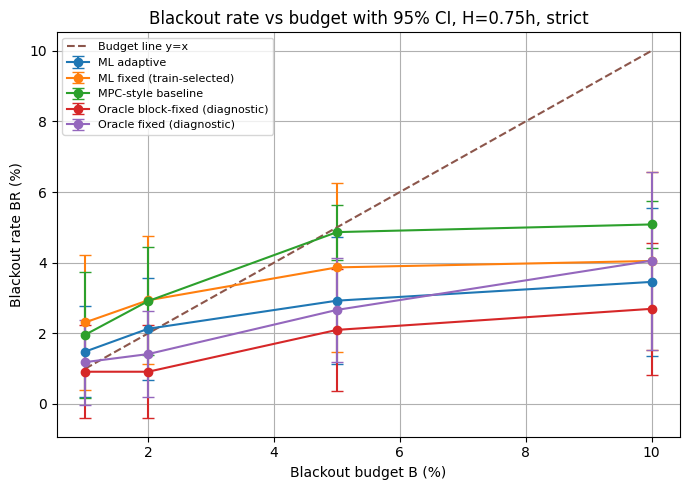

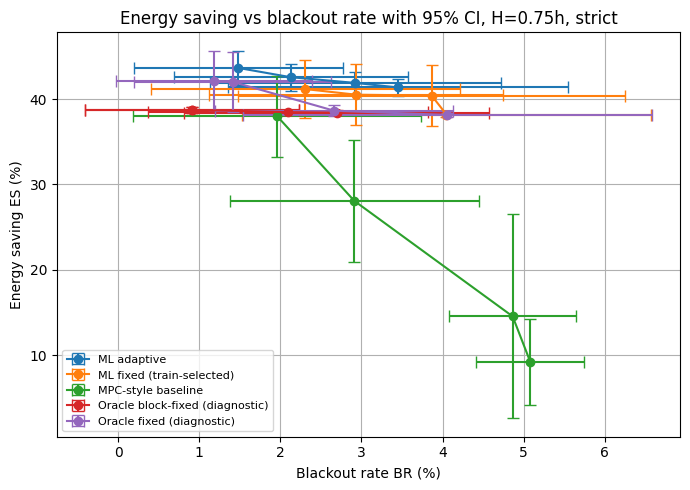

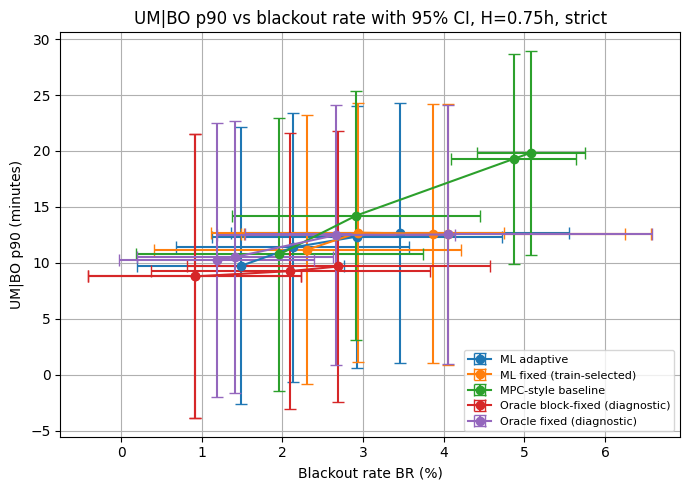

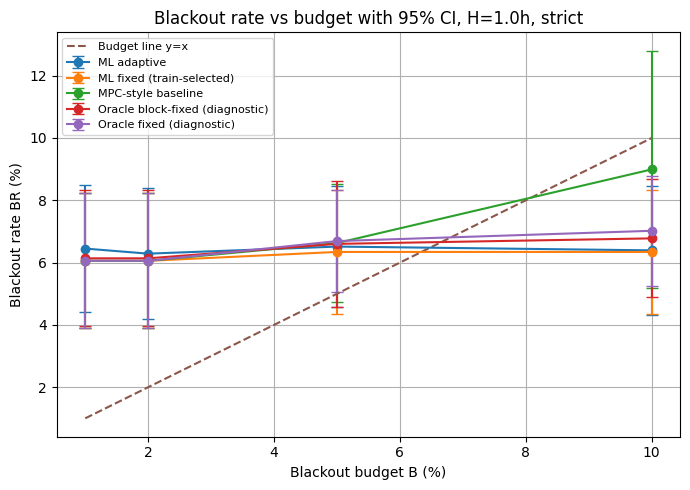

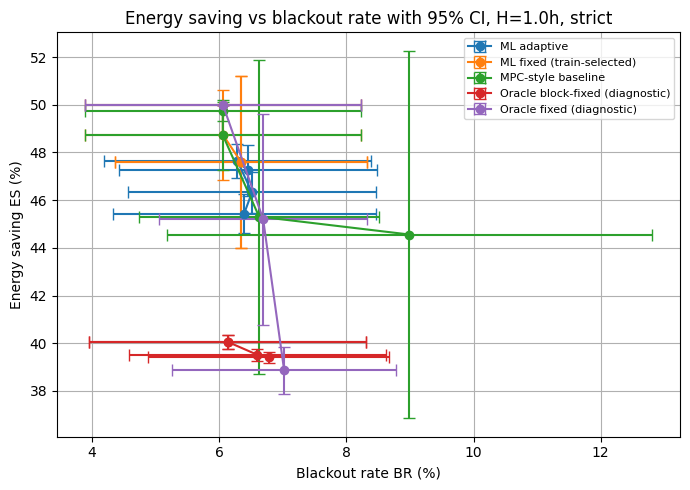

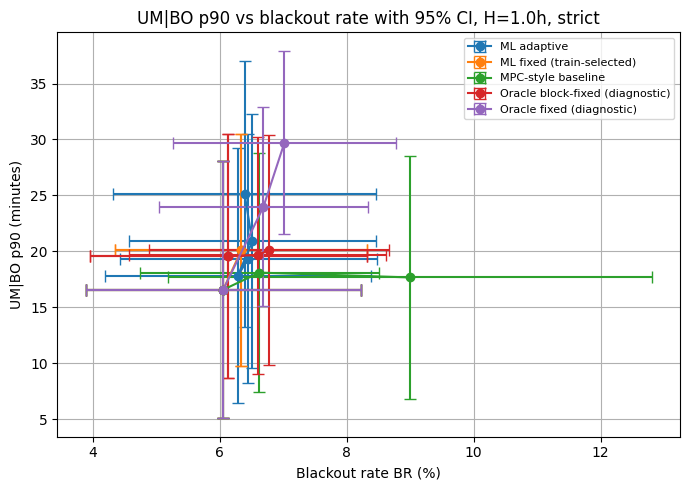

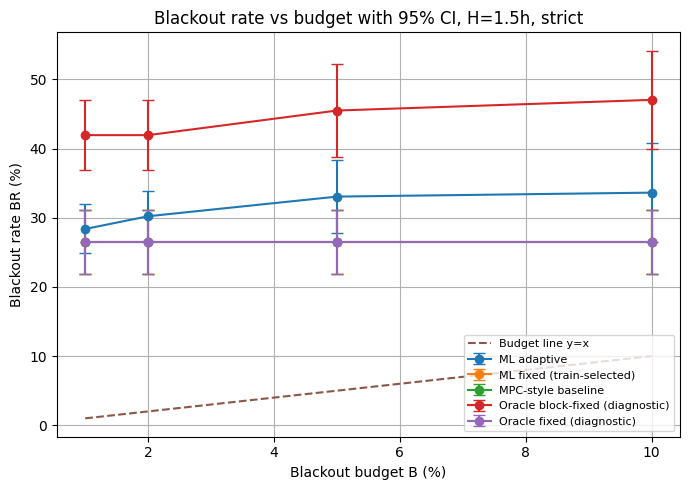

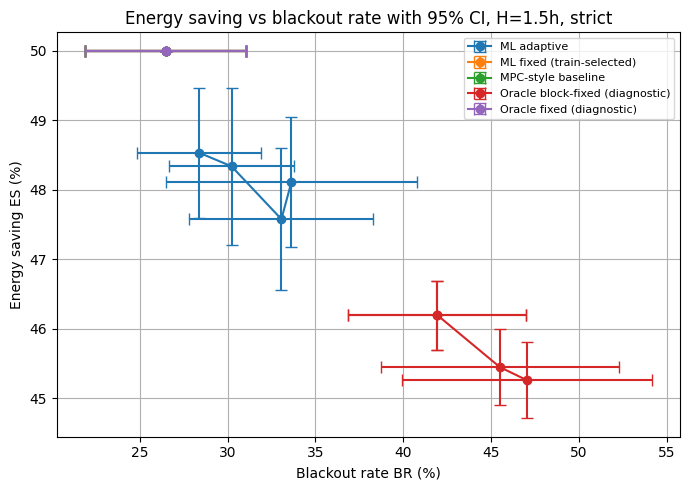

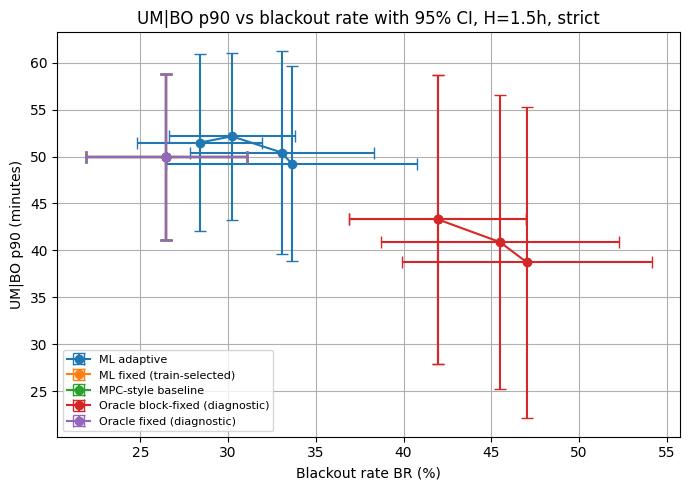


Repeated-run design note:
main_protocol: standard
main_model: rf
main_alpha: 0.2
main_buffer: fixed
n_split_seeds: 5
split_seeds: [0, 1, 2, 3, 4]
n_model_seeds: 2
model_seeds: [0, 1]
n_rows_used_for_ci: 630
ci_method: mean ± t-based 95% confidence interval across repeated grouped split/model-seed runs
baseline_note: Baseline rows were deduplicated by split seed because baselines do not depend on model seed.

Saved outputs to: /content/review_R1_major2_CI_outputs


In [ ]:
# ==========================================================
# R1 Major Comment 2:
# Statistical reliability of reported results
# Repeated grouped split / model-seed 95% confidence intervals
#
# Use this after trade_master has been created.
# Recommended final run:
#   MODE = "review_fast"
#   PROTOCOLS = ["standard"]
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

try:
    from scipy.stats import t
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

OUTDIR = Path("review_R1_major2_CI_outputs")
OUTDIR.mkdir(exist_ok=True)

# -----------------------------
# Main paper configuration
# -----------------------------
MAIN_PROTOCOL = "standard"
MAIN_MODEL = "rf"
MAIN_ALPHA = 0.20
MAIN_BUFFER = "fixed"

PAPER_POLICIES = [
    "Floors-only baseline",
    "Part-night baseline (100/50/70)",
    "ML fixed (train-selected)",
    "ML adaptive",
    "MPC-style baseline",
    "Oracle fixed (diagnostic)",
    "Oracle block-fixed (diagnostic)",
]

DEPLOYABLE_AND_ORACLE = [
    "ML fixed (train-selected)",
    "ML adaptive",
    "MPC-style baseline",
    "Oracle fixed (diagnostic)",
    "Oracle block-fixed (diagnostic)",
]

METRICS = [
    "blackout_rate",
    "energy_saving",
    "unmet_minutes_blackout_p90",
]

assert "trade_master" in globals(), "Run the main experiment first so trade_master exists."

df = trade_master.copy()

# ----------------------------------------------------------
# Filter to main manuscript protocol/model only
# ----------------------------------------------------------
df = df[
    (df["protocol"] == MAIN_PROTOCOL) &
    (df["model"] == MAIN_MODEL)
].copy()

# Keep baselines plus main residual-buffer setting.
is_baseline = df["buffer_mode"].eq("baseline")
is_main_setting = (
    df["buffer_mode"].eq(MAIN_BUFFER) &
    np.isclose(df["alpha"], MAIN_ALPHA)
)

df = df[is_baseline | is_main_setting].copy()
df = df[df["Policy"].isin(PAPER_POLICIES)].copy()

if df.empty:
    raise ValueError(
        "No rows after filtering. Check MAIN_PROTOCOL, MAIN_MODEL, MAIN_ALPHA, "
        "MAIN_BUFFER, and policy names."
    )

# ----------------------------------------------------------
# Avoid fake precision for baselines
# Baselines do not depend on model_seed, so repeated model_seed rows
# would duplicate the same baseline result.
# ----------------------------------------------------------
baseline_df = df[df["buffer_mode"].eq("baseline")].copy()
nonbaseline_df = df[~df["buffer_mode"].eq("baseline")].copy()

baseline_df = baseline_df.drop_duplicates(
    subset=[
        "protocol",
        "split_seed",
        "Scenario",
        "Night_h",
        "Budget",
        "Policy",
        "buffer_mode",
    ]
)

# Replicate ID:
# - baselines: split_seed only
# - model-driven policies: split_seed × model_seed
baseline_df["replicate_id"] = baseline_df["split_seed"].astype(str)
nonbaseline_df["replicate_id"] = (
    nonbaseline_df["split_seed"].astype(str) + "_" +
    nonbaseline_df["model_seed"].astype(str)
)

df_ci = pd.concat([baseline_df, nonbaseline_df], ignore_index=True)

# ----------------------------------------------------------
# Diagnostics on repeated-run design
# ----------------------------------------------------------
split_seeds_used = sorted([int(x) for x in df_ci["split_seed"].dropna().unique()])
model_seeds_used = sorted([int(x) for x in df_ci["model_seed"].dropna().unique()])
n_split = len(split_seeds_used)
n_model = len(model_seeds_used)

print("Rows used for CI:", len(df_ci))
print("Split seeds:", split_seeds_used)
print("Model seeds:", model_seeds_used)
print("Policies:", sorted(df_ci["Policy"].unique()))
print("Scenarios:", sorted(df_ci["Scenario"].dropna().unique()))
print(f"\nRepeated-run design: {n_split} split seeds × {n_model} model seeds")

if n_split < 5:
    print(
        "WARNING: Fewer than 5 split seeds detected. "
        "This is okay for debugging but weak for the manuscript."
    )

if n_model < 2:
    print(
        "WARNING: Fewer than 2 model seeds detected. "
        "This does not fully address stochastic model-training variability."
    )

# ==========================================================
# Helper functions
# ==========================================================

def mean_ci95(x):
    """
    Mean and t-based 95% CI across repeated runs.
    """
    x = pd.Series(x).dropna().astype(float)
    n = len(x)

    if n == 0:
        return pd.Series({
            "mean": np.nan,
            "std": np.nan,
            "n": 0,
            "ci95_low": np.nan,
            "ci95_high": np.nan,
            "ci95_half_width": np.nan,
        })

    mean = float(x.mean())
    std = float(x.std(ddof=1)) if n > 1 else 0.0

    if n > 1:
        crit = float(t.ppf(0.975, df=n - 1)) if SCIPY_AVAILABLE else 1.96
        half_width = crit * std / np.sqrt(n)
    else:
        half_width = 0.0

    return pd.Series({
        "mean": mean,
        "std": std,
        "n": n,
        "ci95_low": mean - half_width,
        "ci95_high": mean + half_width,
        "ci95_half_width": half_width,
    })


def summarize_ci(data, group_cols, metrics):
    rows = []

    for keys, g in data.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)

        base = dict(zip(group_cols, keys))

        for metric in metrics:
            stats = mean_ci95(g[metric])
            row = base.copy()
            row["metric"] = metric
            row.update(stats.to_dict())
            rows.append(row)

    return pd.DataFrame(rows)


def wide_ci_table(ci_long, index_cols):
    wide = ci_long.pivot_table(
        index=index_cols,
        columns="metric",
        values=["mean", "std", "ci95_low", "ci95_high", "ci95_half_width", "n"],
        aggfunc="first",
    ).reset_index()

    wide.columns = [
        "_".join([str(c) for c in col if str(c) != ""]).strip("_")
        for col in wide.columns
    ]

    return wide


def format_mean_ci(mean, low, high, digits=2):
    if pd.isna(mean):
        return ""
    return f"{mean:.{digits}f} [{low:.{digits}f}, {high:.{digits}f}]"


def add_formatted_ci_columns(wide_df, metric_names, digits=2):
    out = wide_df.copy()

    for metric in metric_names:
        mean_col = f"mean_{metric}"
        low_col = f"ci95_low_{metric}"
        high_col = f"ci95_high_{metric}"

        if all(c in out.columns for c in [mean_col, low_col, high_col]):
            out[f"{metric}_mean_95CI"] = out.apply(
                lambda r: format_mean_ci(
                    r[mean_col],
                    r[low_col],
                    r[high_col],
                    digits=digits,
                ),
                axis=1,
            )

    return out


# ==========================================================
# A) Table 3 replacement:
# BR_min(H) under floors-only baseline with 95% CI
# ==========================================================

brmin_df = df_ci[
    (df_ci["Scenario"].eq("strict")) &
    (df_ci["Policy"].eq("Floors-only baseline"))
].copy()

if brmin_df.empty:
    raise ValueError("No floors-only baseline rows found for Table 3 CI.")

table3_ci_long = summarize_ci(
    brmin_df,
    group_cols=["Night_h"],
    metrics=["blackout_rate", "energy_saving", "unmet_minutes_blackout_p90"],
)

table3_ci = wide_ci_table(table3_ci_long, ["Night_h"])
table3_ci = table3_ci.sort_values("Night_h").reset_index(drop=True)

table3_ci["BR_min_95CI_text"] = table3_ci.apply(
    lambda r: format_mean_ci(
        r["mean_blackout_rate"],
        r["ci95_low_blackout_rate"],
        r["ci95_high_blackout_rate"],
        digits=2,
    ),
    axis=1,
)

table3_ci["UMBO_p90_95CI_text"] = table3_ci.apply(
    lambda r: format_mean_ci(
        r["mean_unmet_minutes_blackout_p90"],
        r["ci95_low_unmet_minutes_blackout_p90"],
        r["ci95_high_unmet_minutes_blackout_p90"],
        digits=2,
    ),
    axis=1,
)

table3_ci.to_csv(
    OUTDIR / "Table3_BRmin_floors_only_95CI.csv",
    index=False,
)

table3_manuscript = table3_ci[
    [
        "Night_h",
        "BR_min_95CI_text",
        "UMBO_p90_95CI_text",
        "n_blackout_rate",
    ]
].copy()

table3_manuscript = table3_manuscript.rename(columns={
    "Night_h": "H",
    "BR_min_95CI_text": "BR_min_mean_95CI",
    "UMBO_p90_95CI_text": "UMBO_p90_mean_95CI",
    "n_blackout_rate": "n_repeats",
})

table3_manuscript.to_csv(
    OUTDIR / "Table3_manuscript_ready_BRmin_95CI.csv",
    index=False,
)

print("\n=== Table 3 replacement: BR_min(H) with 95% CI ===")
display(table3_manuscript)


# ==========================================================
# B) Main Section X result curves:
# BR, ES, and UM|BO p90 with 95% CI
# ==========================================================

curve_df = df_ci[df_ci["Budget"].notna()].copy()

if curve_df.empty:
    raise ValueError("No budgeted rows found for Section X curve CI.")

curve_ci_long = summarize_ci(
    curve_df,
    group_cols=["Scenario", "Night_h", "Budget", "Policy"],
    metrics=METRICS,
)

curve_ci = wide_ci_table(
    curve_ci_long,
    ["Scenario", "Night_h", "Budget", "Policy"],
)

curve_ci = curve_ci.sort_values(
    ["Scenario", "Night_h", "Budget", "Policy"]
).reset_index(drop=True)

curve_ci.to_csv(
    OUTDIR / "SectionX_curves_BR_ES_UMBOp90_95CI.csv",
    index=False,
)

curve_ci_formatted = add_formatted_ci_columns(
    curve_ci,
    metric_names=[
        "blackout_rate",
        "energy_saving",
        "unmet_minutes_blackout_p90",
    ],
    digits=2,
)

curve_ci_formatted.to_csv(
    OUTDIR / "SectionX_curves_manuscript_ready_mean_95CI.csv",
    index=False,
)

print("\n=== Section X curve values with 95% CI ===")
display(curve_ci_formatted.head(40))


# ==========================================================
# C) Alignment check:
# BR - BR_min(H), supporting statements such as
# "aligning with BR_min(1.0 h)"
# ==========================================================

floor_by_split = brmin_df[
    ["split_seed", "Night_h", "blackout_rate"]
].drop_duplicates(
    subset=["split_seed", "Night_h"]
).rename(
    columns={"blackout_rate": "BR_min_floors"}
)

policy_df = curve_df[
    curve_df["Policy"].isin(DEPLOYABLE_AND_ORACLE)
].copy()

policy_vs_floor = policy_df.merge(
    floor_by_split,
    on=["split_seed", "Night_h"],
    how="left",
)

if policy_vs_floor["BR_min_floors"].isna().any():
    missing_count = int(policy_vs_floor["BR_min_floors"].isna().sum())
    print(f"WARNING: {missing_count} rows missing BR_min_floors after merge.")

policy_vs_floor["BR_minus_BRmin"] = (
    policy_vs_floor["blackout_rate"] - policy_vs_floor["BR_min_floors"]
)

alignment_ci_long = summarize_ci(
    policy_vs_floor,
    group_cols=["Scenario", "Night_h", "Budget", "Policy"],
    metrics=["BR_minus_BRmin"],
)

alignment_ci = wide_ci_table(
    alignment_ci_long,
    ["Scenario", "Night_h", "Budget", "Policy"],
)

alignment_ci = alignment_ci.sort_values(
    ["Scenario", "Night_h", "Budget", "Policy"]
).reset_index(drop=True)

alignment_ci["BR_minus_BRmin_95CI_text"] = alignment_ci.apply(
    lambda r: format_mean_ci(
        r["mean_BR_minus_BRmin"],
        r["ci95_low_BR_minus_BRmin"],
        r["ci95_high_BR_minus_BRmin"],
        digits=2,
    ),
    axis=1,
)

alignment_ci.to_csv(
    OUTDIR / "Alignment_policy_BR_minus_BRmin_95CI.csv",
    index=False,
)

print("\n=== Alignment with BR_min(H): BR - BR_min with 95% CI ===")
display(alignment_ci.head(40))


# ==========================================================
# D) Plots with 95% CI error bars
# These can replace deterministic Figures 3-5 or be used as appendix figures.
# ==========================================================

def plot_br_vs_budget_ci(ci_wide, H, scenario="strict", policies=None):
    s = ci_wide[
        (np.isclose(ci_wide["Night_h"], H)) &
        (ci_wide["Scenario"].eq(scenario))
    ].copy()

    if policies is not None:
        s = s[s["Policy"].isin(policies)].copy()

    if s.empty:
        print(f"No rows for H={H}, scenario={scenario}")
        return

    plt.figure(figsize=(7, 5))

    for pol in sorted(s["Policy"].unique()):
        tpol = s[s["Policy"].eq(pol)].sort_values("Budget")

        plt.errorbar(
            tpol["Budget"],
            tpol["mean_blackout_rate"],
            yerr=tpol["ci95_half_width_blackout_rate"],
            marker="o",
            capsize=4,
            label=pol,
        )

    xs = sorted(s["Budget"].dropna().unique())
    plt.plot(xs, xs, linestyle="--", label="Budget line y=x")

    plt.title(f"Blackout rate vs budget with 95% CI, H={H}h, {scenario}")
    plt.xlabel("Blackout budget B (%)")
    plt.ylabel("Blackout rate BR (%)")
    plt.grid(True)
    plt.legend(fontsize=8)
    plt.tight_layout()

    fname = OUTDIR / f"Fig_BR_vs_budget_CI_H{str(H).replace('.', '_')}_{scenario}.png"
    plt.savefig(fname, dpi=300)
    plt.show()


def plot_es_vs_br_ci(ci_wide, H, scenario="strict", policies=None):
    s = ci_wide[
        (np.isclose(ci_wide["Night_h"], H)) &
        (ci_wide["Scenario"].eq(scenario))
    ].copy()

    if policies is not None:
        s = s[s["Policy"].isin(policies)].copy()

    if s.empty:
        print(f"No rows for H={H}, scenario={scenario}")
        return

    plt.figure(figsize=(7, 5))

    for pol in sorted(s["Policy"].unique()):
        tpol = s[s["Policy"].eq(pol)].sort_values("Budget")

        plt.errorbar(
            tpol["mean_blackout_rate"],
            tpol["mean_energy_saving"],
            xerr=tpol["ci95_half_width_blackout_rate"],
            yerr=tpol["ci95_half_width_energy_saving"],
            marker="o",
            capsize=4,
            label=pol,
        )

    plt.title(f"Energy saving vs blackout rate with 95% CI, H={H}h, {scenario}")
    plt.xlabel("Blackout rate BR (%)")
    plt.ylabel("Energy saving ES (%)")
    plt.grid(True)
    plt.legend(fontsize=8)
    plt.tight_layout()

    fname = OUTDIR / f"Fig_ES_vs_BR_CI_H{str(H).replace('.', '_')}_{scenario}.png"
    plt.savefig(fname, dpi=300)
    plt.show()


def plot_severity_vs_br_ci(ci_wide, H, scenario="strict", policies=None):
    s = ci_wide[
        (np.isclose(ci_wide["Night_h"], H)) &
        (ci_wide["Scenario"].eq(scenario))
    ].copy()

    if policies is not None:
        s = s[s["Policy"].isin(policies)].copy()

    if s.empty:
        print(f"No rows for H={H}, scenario={scenario}")
        return

    plt.figure(figsize=(7, 5))

    for pol in sorted(s["Policy"].unique()):
        tpol = s[s["Policy"].eq(pol)].sort_values("Budget")

        plt.errorbar(
            tpol["mean_blackout_rate"],
            tpol["mean_unmet_minutes_blackout_p90"],
            xerr=tpol["ci95_half_width_blackout_rate"],
            yerr=tpol["ci95_half_width_unmet_minutes_blackout_p90"],
            marker="o",
            capsize=4,
            label=pol,
        )

    plt.title(f"UM|BO p90 vs blackout rate with 95% CI, H={H}h, {scenario}")
    plt.xlabel("Blackout rate BR (%)")
    plt.ylabel("UM|BO p90 (minutes)")
    plt.grid(True)
    plt.legend(fontsize=8)
    plt.tight_layout()

    fname = OUTDIR / f"Fig_UMBOp90_vs_BR_CI_H{str(H).replace('.', '_')}_{scenario}.png"
    plt.savefig(fname, dpi=300)
    plt.show()


for scenario in sorted(curve_ci["Scenario"].dropna().unique()):
    for H in sorted(curve_ci["Night_h"].dropna().unique()):
        plot_br_vs_budget_ci(
            curve_ci,
            H=H,
            scenario=scenario,
            policies=DEPLOYABLE_AND_ORACLE,
        )

        plot_es_vs_br_ci(
            curve_ci,
            H=H,
            scenario=scenario,
            policies=DEPLOYABLE_AND_ORACLE,
        )

        plot_severity_vs_br_ci(
            curve_ci,
            H=H,
            scenario=scenario,
            policies=DEPLOYABLE_AND_ORACLE,
        )


# ==========================================================
# E) Save repeated-run design note for reviewer response
# ==========================================================

design_note = {
    "main_protocol": MAIN_PROTOCOL,
    "main_model": MAIN_MODEL,
    "main_alpha": MAIN_ALPHA,
    "main_buffer": MAIN_BUFFER,
    "n_split_seeds": int(n_split),
    "split_seeds": split_seeds_used,
    "n_model_seeds": int(n_model),
    "model_seeds": model_seeds_used,
    "n_rows_used_for_ci": int(len(df_ci)),
    "ci_method": "mean ± t-based 95% confidence interval across repeated grouped split/model-seed runs",
    "baseline_note": "Baseline rows were deduplicated by split seed because baselines do not depend on model seed.",
}

pd.Series(design_note).to_csv(
    OUTDIR / "R1_major2_repeated_run_design_note.csv"
)

print("\nRepeated-run design note:")
for k, v in design_note.items():
    print(f"{k}: {v}")

print("\nSaved outputs to:", OUTDIR.resolve())

In [ ]:
print("mrm")

In [ ]:
# ==========================
# Cell 8 — Robustness Summary (median + IQR) [FIXED + SIMPLE]
# ==========================

import numpy as np
import pandas as pd

df = trade_master.copy()
df_strict = df[df["Scenario"].eq("strict")].copy()

group_cols = ["protocol", "model", "Policy", "Night_h", "Budget", "alpha", "buffer_mode"]

metrics = ["blackout_rate", "energy_saving", "unmet_minutes_blackout_p90"]

agg_dict = {}
for m in metrics:
    agg_dict[f"{m}_median"] = (m, "median")
    agg_dict[f"{m}_q25"] = (m, lambda x: float(np.quantile(x, 0.25)))
    agg_dict[f"{m}_q75"] = (m, lambda x: float(np.quantile(x, 0.75)))

summary = (
    df_strict
    .groupby(group_cols, dropna=False)
    .agg(**agg_dict)
    .reset_index()
)

summary.to_csv("robust_summary.csv", index=False)
print("Saved: robust_summary.csv | rows:", len(summary))
display(summary.head(15))

Saved: robust_summary.csv | rows: 366


,protocol,model,Policy,Night_h,Budget,alpha,buffer_mode,blackout_rate_median,blackout_rate_q25,blackout_rate_q75,energy_saving_median,energy_saving_q25,energy_saving_q75,unmet_minutes_blackout_p90_median,unmet_minutes_blackout_p90_q25,unmet_minutes_blackout_p90_q75
0,standard,rf,Floors-only baseline,0.75,NaN,NaN,baseline,0.000000,0.000000,0.000000,50.000000,50.000000,50.000000,0.000000,0.000000,0.000000
1,standard,rf,Floors-only baseline,1.00,NaN,NaN,baseline,6.233766,3.133903,8.640864,50.000000,50.000000,50.000000,13.101556,5.872400,14.597222
2,standard,rf,Floors-only baseline,1.50,NaN,NaN,baseline,25.266362,21.553090,32.987013,50.000000,50.000000,50.000000,54.768976,39.654056,55.309524
3,standard,rf,ML adaptive,0.75,1.0,0.05,fixed,0.792465,0.158479,2.604025,42.041398,41.391934,45.120781,1.895688,1.358333,2.345382
4,standard,rf,ML adaptive,0.75,1.0,0.05,none,1.159738,0.000000,2.786871,42.351366,41.999412,43.086987,3.239009,0.000000,4.843995
5,standard,rf,ML adaptive,0.75,1.0,0.10,fixed,0.411947,0.000000,2.231809,43.264422,42.626374,43.485847,2.138717,0.000000,5.460586
6,standard,rf,ML adaptive,0.75,1.0,0.10,none,1.159738,0.000000,2.786871,42.351366,41.999412,43.086987,3.239009,0.000000,4.843995
7,standard,rf,ML adaptive,0.75,1.0,0.20,fixed,0.671688,0.000000,2.460120,43.305472,43.095188,43.564501,2.335250,0.000000,4.205807
8,standard,rf,ML adaptive,0.75,1.0,0.20,none,1.159738,0.000000,2.786871,42.351366,41.999412,43.086987,3.239009,0.000000,4.843995
9,standard,rf,ML adaptive,0.75,2.0,0.05,fixed,1.826484,0.158479,3.441558,41.990412,41.529394,42.913767,8.565966,1.358333,9.581597


In [ ]:
MAIN_ALPHA = 0.20
MAIN_BUFFER = "fixed"
MAIN_MODEL = "rf"

cmp = summary[
    (summary["alpha"] == MAIN_ALPHA) &
    (summary["buffer_mode"].isin([MAIN_BUFFER, "baseline"])) &
    (summary["model"] == MAIN_MODEL)
].copy()

display(cmp.sort_values(["protocol","Night_h","Budget","Policy"]).head(30))

,protocol,model,Policy,Night_h,Budget,alpha,buffer_mode,blackout_rate_median,blackout_rate_q25,blackout_rate_q75,energy_saving_median,energy_saving_q25,energy_saving_q75,unmet_minutes_blackout_p90_median,unmet_minutes_blackout_p90_q25,unmet_minutes_blackout_p90_q75
7,standard,rf,ML adaptive,0.75,1.0,0.2,fixed,0.671688,0.000000,2.460120,43.305472,43.095188,43.564501,2.335250,0.000000,4.205807
79,standard,rf,ML fixed (train-selected),0.75,1.0,0.2,fixed,0.837139,0.158479,4.320432,38.953047,38.056651,40.963099,2.597105,1.358333,9.597222
151,standard,rf,MPC-style baseline,0.75,1.0,0.2,fixed,0.158479,0.000000,4.320432,39.361483,32.527870,42.842467,2.046446,0.000000,9.404514
223,standard,rf,Oracle block-fixed (diagnostic),0.75,1.0,0.2,fixed,0.000000,0.000000,0.152207,38.954783,38.464063,39.057827,0.000000,0.000000,1.588033
295,standard,rf,Oracle fixed (diagnostic),0.75,1.0,0.2,fixed,0.633914,0.064935,0.875190,40.536715,38.000000,44.490131,2.924124,0.496617,5.251627
13,standard,rf,ML adaptive,0.75,2.0,0.2,fixed,2.207002,0.000000,4.216922,41.349652,41.110240,44.233460,5.016256,0.000000,9.519097
85,standard,rf,ML fixed (train-selected),0.75,2.0,0.2,fixed,3.805175,0.316957,4.320432,38.219365,38.000000,38.352686,9.597222,1.923653,9.597222
157,standard,rf,MPC-style baseline,0.75,2.0,0.2,fixed,2.587519,1.109350,4.320432,24.577716,21.772747,28.511568,7.149281,5.428132,14.945583
229,standard,rf,Oracle block-fixed (diagnostic),0.75,2.0,0.2,fixed,0.000000,0.000000,0.152207,38.954783,38.464063,39.057827,0.000000,0.000000,1.588033
301,standard,rf,Oracle fixed (diagnostic),0.75,2.0,0.2,fixed,0.633914,0.064935,1.978691,39.795184,38.000000,44.490131,3.242450,0.496617,6.100048


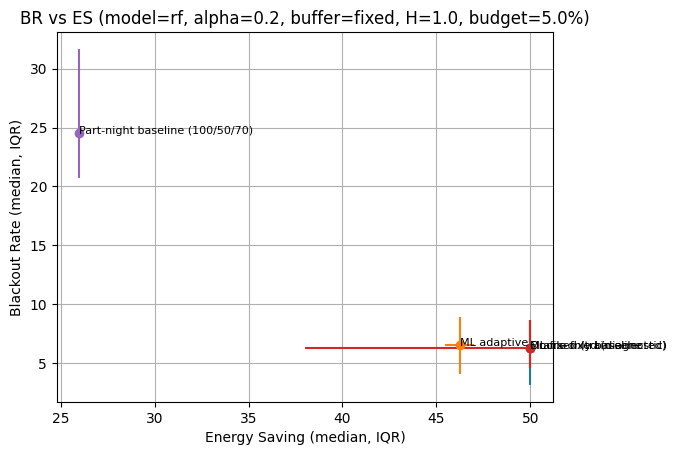

In [ ]:
# ==========================
# Cell 9 — Simple plot (BR vs ES) for main setting
# ==========================

import matplotlib.pyplot as plt
import numpy as np

df = summary.copy()   # <-- fixed

MAIN_ALPHA = 0.20
MAIN_BUFFER = "fixed"
MAIN_MODEL = "rf"

# Filter main setting (keep baselines too)
d = df[
    (df["model"] == MAIN_MODEL) &
    (
        (df["buffer_mode"] == MAIN_BUFFER) |
        (df["buffer_mode"] == "baseline")
    )
].copy()

# Keep only selected policies
keep_policies = [
    "Floors-only baseline",
    "Part-night baseline (100/50/70)",
    "ML fixed (train-selected)",
    "ML adaptive",
    "Oracle fixed (diagnostic)",
]
d = d[d["Policy"].isin(keep_policies)]

# Choose one horizon + budget to keep plot clean
H_SHOW = 1.0
B_SHOW = 5.0

d2 = d[(d["Night_h"] == H_SHOW) & ((d["Budget"].isna()) | (d["Budget"] == B_SHOW))].copy()

# For non-baseline rows, select alpha/buffer
d2 = d2[
    (d2["buffer_mode"] == "baseline") |
    ((d2["buffer_mode"] == MAIN_BUFFER) & (np.isclose(d2["alpha"], MAIN_ALPHA)))
].copy()

plt.figure()
for _, r in d2.iterrows():
    x = r["energy_saving_median"]
    y = r["blackout_rate_median"]

    # IQR “error bars”
    xerr = [[x - r["energy_saving_q25"]], [r["energy_saving_q75"] - x]]
    yerr = [[y - r["blackout_rate_q25"]], [r["blackout_rate_q75"] - y]]

    plt.errorbar(x, y, xerr=xerr, yerr=yerr, fmt="o")
    plt.text(x, y, r["Policy"], fontsize=8)

plt.xlabel("Energy Saving (median, IQR)")
plt.ylabel("Blackout Rate (median, IQR)")
plt.title(f"BR vs ES (model={MAIN_MODEL}, alpha={MAIN_ALPHA}, buffer={MAIN_BUFFER}, H={H_SHOW}, budget={B_SHOW}%)")
plt.grid(True)
plt.show()

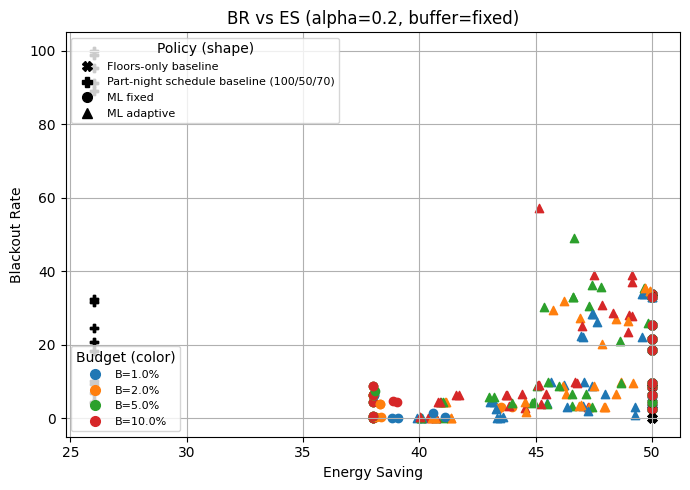

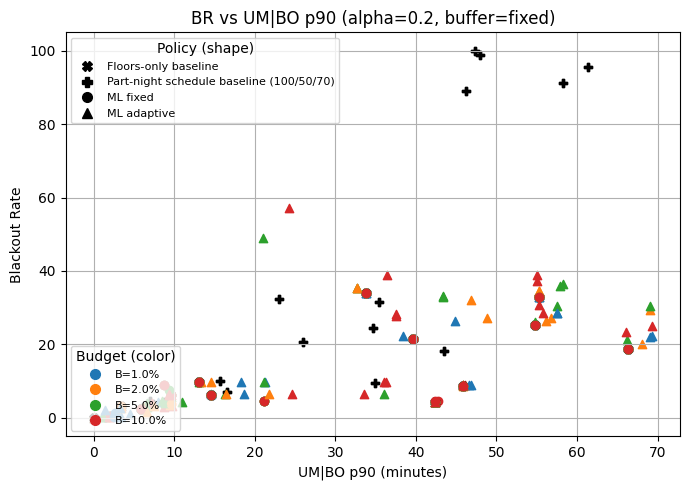

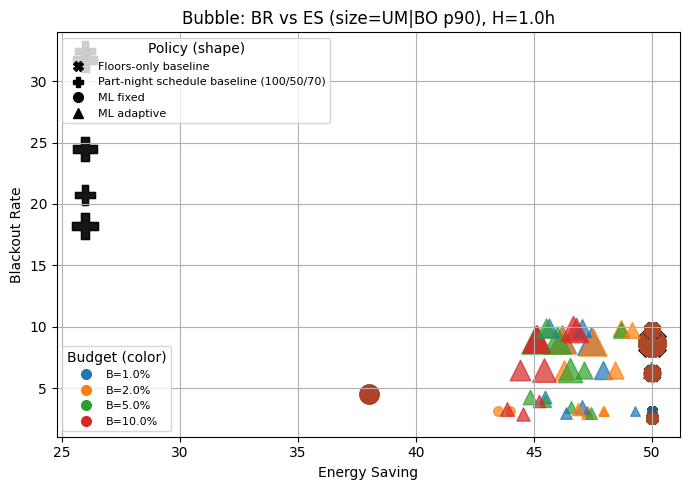

In [ ]:
# ==========================================
# Paper-ready plots (same style as old pipeline)
# 1) BR vs ES (shape=policy, color=budget)
# 2) BR vs UM|BO p90 (shape=policy, color=budget)
# 3) Bubble plot (optional): BR vs ES, size=UM|BO p90 (for H=1.0 only)
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

assert "trade_master" in globals() and len(trade_master) > 0, "Run Cell 7 first (trade_master not found)."

# ---- Pick the main config you want to plot (same as paper) ----
MAIN_ALPHA = 0.20
MAIN_BUFFER = "fixed"   # "fixed" or "none"
SHOW_BUBBLE_FOR_H = 1.0 # set None to disable bubble plot
EXCLUDE_ORACLES = True  # keep clean like paper

# ---- Build trade_plot from your master ----
trade_plot = trade_master.copy()

# Keep only strict scenario
trade_plot = trade_plot[trade_plot["Scenario"] == "strict"].copy()

# Keep baselines + main alpha/buffer
is_baseline = trade_plot["buffer_mode"].eq("baseline")
is_main = (trade_plot["buffer_mode"].eq(MAIN_BUFFER)) & (np.isclose(trade_plot["alpha"], MAIN_ALPHA))
trade_plot = trade_plot[is_baseline | is_main].copy()

# Rename policies to match paper labels (old notebook style)
rename_policy = {
    "Part-night baseline (100/50/70)": "Part-night schedule baseline (100/50/70)",
    "ML fixed (train-selected)": "ML fixed",
    "ML adaptive": "ML adaptive",
    "Floors-only baseline": "Floors-only baseline",
    "Oracle fixed (diagnostic)": "Oracle fixed",
    "Oracle block-fixed (diagnostic)": "Oracle block-fixed (B=30)",
}
trade_plot["Policy_paper"] = trade_plot["Policy"].map(rename_policy).fillna(trade_plot["Policy"])

if EXCLUDE_ORACLES:
    trade_plot = trade_plot[~trade_plot["Policy_paper"].str.contains("Oracle", case=False, na=False)].copy()

# ---- Policy → marker mapping (paper style) ----
policy_markers = {
    "Floors-only baseline": "X",
    "Part-night schedule baseline (100/50/70)": "P",
    "ML fixed": "o",
    "ML adaptive": "^",
    "ML block-fixed (B=30)": "s",  # only if you later add it
}

# Policies to show (only those that exist)
policies_order = [
    "Floors-only baseline",
    "Part-night schedule baseline (100/50/70)",
    "ML fixed",
    "ML adaptive",
    "ML block-fixed (B=30)",
]
policies_order = [p for p in policies_order if p in set(trade_plot["Policy_paper"])]

# ---- Budget → default matplotlib colors (no hardcoded palette) ----
budgets_sorted = sorted([float(b) for b in BUDGETS_EXT if not np.isnan(b)])
cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", ["C0","C1","C2","C3"])
budget_colors = {bud: cycle[i % len(cycle)] for i, bud in enumerate(budgets_sorted)}

def two_legends(ax):
    # policy legend (shapes)
    policy_handles = [
        mlines.Line2D([], [], color="k", marker=policy_markers[p],
                      linestyle="None", markersize=7, label=p)
        for p in policies_order if p in policy_markers
    ]
    # budget legend (colors)
    budget_handles = [
        mlines.Line2D([], [], color=budget_colors[b], marker="o",
                      linestyle="None", markersize=7, label=f"B={b}%")
        for b in budgets_sorted
    ]
    leg1 = ax.legend(handles=policy_handles, loc="upper left", fontsize=8, title="Policy (shape)")
    ax.add_artist(leg1)
    ax.legend(handles=budget_handles, loc="lower left", fontsize=8, title="Budget (color)")

# ---- Plot 1: BR vs ES ----
plt.figure(figsize=(7, 5))
ax = plt.gca()

for _, r in trade_plot.iterrows():
    pol = r["Policy_paper"]
    if pol not in policy_markers:
        continue

    bud = r["Budget"]
    if np.isnan(bud):
        # baselines -> color them black
        col = "k"
    else:
        col = budget_colors.get(float(bud), "C0")

    ax.scatter(r["energy_saving"], r["blackout_rate"], marker=policy_markers[pol], color=col)

ax.set_title(f"BR vs ES (alpha={MAIN_ALPHA}, buffer={MAIN_BUFFER})")
ax.set_xlabel("Energy Saving")
ax.set_ylabel("Blackout Rate")
ax.grid(True)
two_legends(ax)
plt.tight_layout()
plt.show()

# ---- Plot 2: BR vs UM|BO p90 ----
plt.figure(figsize=(7, 5))
ax = plt.gca()

for _, r in trade_plot.iterrows():
    pol = r["Policy_paper"]
    if pol not in policy_markers:
        continue

    bud = r["Budget"]
    col = "k" if np.isnan(bud) else budget_colors.get(float(bud), "C0")
    ax.scatter(r["unmet_minutes_blackout_p90"], r["blackout_rate"], marker=policy_markers[pol], color=col)

ax.set_title(f"BR vs UM|BO p90 (alpha={MAIN_ALPHA}, buffer={MAIN_BUFFER})")
ax.set_xlabel("UM|BO p90 (minutes)")
ax.set_ylabel("Blackout Rate")
ax.grid(True)
two_legends(ax)
plt.tight_layout()
plt.show()

# ---- Plot 3: Bubble plot (optional, H fixed) ----
if SHOW_BUBBLE_FOR_H is not None:
    dH = trade_plot[np.isclose(trade_plot["Night_h"], float(SHOW_BUBBLE_FOR_H))].copy()

    plt.figure(figsize=(7, 5))
    ax = plt.gca()

    for _, r in dH.iterrows():
        pol = r["Policy_paper"]
        if pol not in policy_markers:
            continue

        bud = r["Budget"]
        col = "k" if np.isnan(bud) else budget_colors.get(float(bud), "C0")

        size = 20 + 8 * float(r["unmet_minutes_blackout_p90"])  # bubble size
        ax.scatter(r["energy_saving"], r["blackout_rate"], s=size, marker=policy_markers[pol], color=col, alpha=0.7)

    ax.set_title(f"Bubble: BR vs ES (size=UM|BO p90), H={SHOW_BUBBLE_FOR_H}h")
    ax.set_xlabel("Energy Saving")
    ax.set_ylabel("Blackout Rate")
    ax.grid(True)
    two_legends(ax)
    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd
import numpy as np

# Use in-memory dataframe if present, else load csv
if "trade_master" in globals():
    df_all = trade_master.copy()
else:
    df_all = pd.read_csv("trade_master.csv")

# Pick one run (the first exp_tag)
RUN_TAG = df_all["exp_tag"].iloc[0]
df_run = df_all[df_all["exp_tag"] == RUN_TAG].copy()

print("RUN_TAG:", RUN_TAG, "| rows:", len(df_run))
print("Scenarios:", sorted(df_run["Scenario"].unique()))
print("Policies:", sorted(df_run["Policy"].unique())[:8], "...")

RUN_TAG: review_fast_standard_split0_rf_seed0_iqr1 | rows: 366
Scenarios: ['strict']
Policies: ['Floors-only baseline', 'ML adaptive', 'ML fixed (train-selected)', 'MPC-style baseline', 'Oracle block-fixed (diagnostic)', 'Oracle fixed (diagnostic)', 'Part-night baseline (100/50/70)'] ...


===== RUN TAG =====
review_fast_standard_split0_rf_seed0_iqr1
Scenarios in run: ['strict']
Policies in run: ['Floors-only baseline', 'ML adaptive', 'ML fixed (train-selected)', 'MPC-style baseline', 'Oracle block-fixed (diagnostic)', 'Oracle fixed (diagnostic)', 'Part-night baseline (100/50/70)']

===== DATA SPLITS =====
Train batteries: 20 | rows: 1488
Test  batteries: 9 | rows: 657

===== TRADE TABLE SUMMARY (means) =====


blackout_rate  energy_saving  \
Night_h Policy                                                          
0.75    Floors-only baseline                  0.000000      50.000000   
        ML adaptive                           0.000000      41.436952   
        ML fixed (train-selected)             0.000000      38.000000   
        MPC-style baseline                    2.481007      15.368356   
        Oracle block-fixed (diagnostic)       0.000000      38.000000   
        Oracle fixed (diagnostic)             0.000000      38.000000   
        Part-night baseline (100/50/70)       4.558405      26.000000   
1.00    Floors-only baseline                  3.133903      50.000000   
        ML adaptive                           3.525641      47.079317   
        ML fixed (train-selected)             3.846154      42.387331   
        MPC-style baseline                    6.837607      37.231325   
        Oracle block-fixed (diagnostic)       3.418803      40.353368   
        Oracle fixed (diagnostic)             3.846154      44.013068   
        Part-night baseline (100/50/70)      32.478632      26.000000   
1.50    Floors-only baseline                 33.903134      50.000000   
        ML adaptive                          38.034188      48.709631   
        ML fixed (train-selected)            33.903134      50.000000   
        MPC-style baseline                   33.903134      50.000000   
        Oracle block-fixed (diagnostic)      45.251662      46.060735   
        Oracle fixed (diagnostic)            33.903134      50.000000   
        Part-night baseline (100/50/70)     100.000000      26.000000   

                                         unmet_minutes_blackout_p90  
Night_h Policy                                                       
0.75    Floors-only baseline                               0.000000  
        ML adaptive                                        0.000000  
        ML fixed (train-selected)                          0.000000  
        MPC-style baseline                                 3.887719  
        Oracle block-fixed (diagnostic)                    0.000000  
        Oracle fixed (diagnostic)                          0.000000  
        Part-night baseline (100/50/70)                    7.052452  
1.00    Floors-only baseline                               3.410400  
        ML adaptive                                        5.523518  
        ML fixed (train-selected)                         12.277894  
        MPC-style baseline                                 6.890174  
        Oracle block-fixed (diagnostic)                    5.749212  
        Oracle fixed (diagnostic)                         12.277894  
        Part-night baseline (100/50/70)                   23.045327  
1.50    Floors-only baseline                              33.795989  
        ML adaptive                                       31.721204  
        ML fixed (train-selected)                         33.795989  
        MPC-style baseline                                33.795989  
        Oracle block-fixed (diagnostic)                   26.213525  
        Oracle fixed (diagnostic)                         33.795989  
        Part-night baseline (100/50/70)                   47.327600


===== BUDGET FEASIBILITY (ML only) =====


,feasible
Policy,
ML adaptive,0.500000
ML fixed (train-selected),0.500000
MPC-style baseline,0.347222
Oracle block-fixed (diagnostic),0.500000
Oracle fixed (diagnostic),0.500000



===== PHASE-LEVEL SANITY (illustrative example) =====
Demo case: H=0.75h, Budget=2.0%, alpha=0.2, buffer=fixed


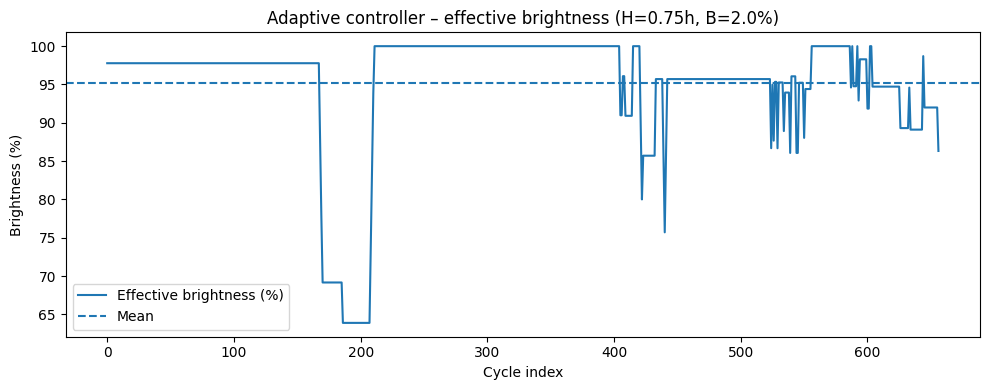

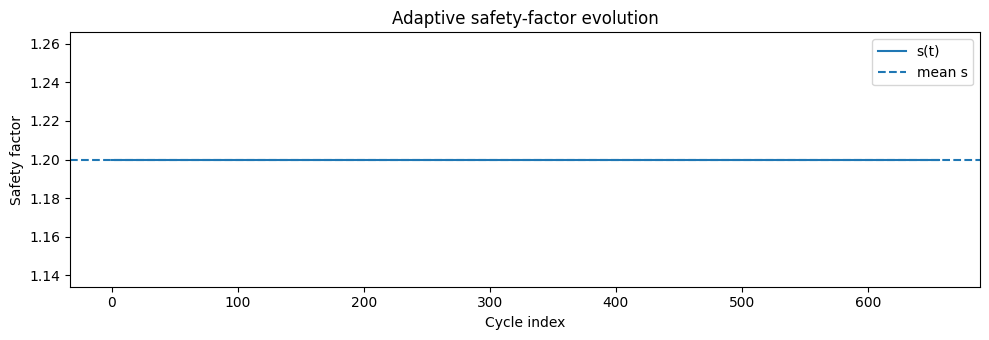


===== RESULTS CHECKS COMPLETE =====


In [ ]:
# ==========================================================
# Results Checks (adapted from old notebook, simple)
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 0) Pick a single run like old "trade_run_seed42_iqr1.csv"
# If you want a specific run, set RUN_TAG manually.
if "trade_master" not in globals():
    trade_master = pd.read_csv("trade_master.csv")

RUN_TAG = trade_master["exp_tag"].iloc[0]
df_run = trade_master[trade_master["exp_tag"] == RUN_TAG].copy()

print("===== RUN TAG =====")
print(RUN_TAG)
print("Scenarios in run:", sorted(df_run["Scenario"].unique()))
print("Policies in run:", sorted(df_run["Policy"].unique()))

# 1) Data split sizes (uses current df_train/df_test)
print("\n===== DATA SPLITS =====")
print("Train batteries:", df_train[GROUP_COL].nunique(), "| rows:", len(df_train))
print("Test  batteries:", df_test[GROUP_COL].nunique(),  "| rows:", len(df_test))

# 2) Trade-table summary means (like old cell)
print("\n===== TRADE TABLE SUMMARY (means) =====")
display(
    df_run.groupby(["Night_h", "Policy"])[
        ["blackout_rate", "energy_saving", "unmet_minutes_blackout_p90"]
    ].mean()
)

# 3) Budget feasibility (ML policies only)
print("\n===== BUDGET FEASIBILITY (ML only) =====")
ml_rows = df_run[df_run["Budget"].notna()].copy()
ml_rows["feasible"] = ml_rows["blackout_rate"] <= (ml_rows["Budget"] + 1e-12)
display(ml_rows.groupby("Policy")["feasible"].mean())

# 4) Phase-level sanity (illustrative example)
# We recreate the adaptive controller trace for plotting (brightness + safety factor).
print("\n===== PHASE-LEVEL SANITY (illustrative example) =====")

MAIN_ALPHA = 0.20
MAIN_BUFFER = "fixed"

# Make sure we have a trained artifact for this run.
# If you already ran fit_predict() earlier, art exists.
assert "art" in globals(), "Run Cell 5 (fit_predict) first so 'art' exists."

# Use MAIN_ALPHA to compute qbuf from OOF residuals
q_alpha = float(np.quantile(art["resid"], 1.0 - MAIN_ALPHA))
qbuf = 0.0 if MAIN_BUFFER == "none" else q_alpha

# Choose a simple demo case
H_demo = float(NIGHTS_H[0])
B_demo = float(BUDGETS[0])
T_demo = H_demo * 3600.0

# Only proceed if ML adaptive row exists
row = df_run[
    (np.isclose(df_run["Night_h"], H_demo)) &
    (df_run["Policy"] == "ML adaptive") &
    (df_run["Budget"].notna()) &
    (np.isclose(df_run["Budget"], B_demo)) &
    (np.isclose(df_run["alpha"], MAIN_ALPHA)) &
    (df_run["buffer_mode"] == MAIN_BUFFER)
]

if len(row) == 0:
    print("No matching ML adaptive row found for demo sanity.")
else:
    print(f"Demo case: H={H_demo}h, Budget={B_demo}%, alpha={MAIN_ALPHA}, buffer={MAIN_BUFFER}")

    y_true = art["y_true"]
    y_hat  = art["y_hat"]

    # ---- Simple trace reconstruction for plots ----
    n = len(y_true)
    s = float(SAFETY_INIT)
    s_hist = np.zeros(n, float)
    pct_avg = np.zeros(n, float)

    floor_avg = sum(PHASE_FLOORS[k] * PHASE_SPLIT[k] for k in PHASE_FLOORS)

    for t in range(n):
        # avg brightness decision at time t
        pct_avg[t] = ml_pct_from_forecast(
            np.array([y_hat[t]]), T_demo, s, qbuf, PHASE_FLOORS, PHASE_SPLIT
        )[0]

        # recent blackout rate window
        start = max(0, t - ADAPT_WINDOW + 1)
        br_recent = float(np.mean(y_true[start:t+1] < T_demo))

        # safety update
        s = s + ADAPT_KP * (B_demo - br_recent)
        s = float(np.clip(s, S_MIN, S_MAX))
        s_hist[t] = s

    # apply actuation realism
    pct_avg = apply_hysteresis_and_ramp(pct_avg, HYSTERESIS, RAMP_LIMIT)

    # convert avg -> effective brightness
    _, _, _, pct_eff, _ = avg_to_phase_arrays(pct_avg, PHASE_FLOORS, PHASE_SPLIT, PRIORITY)

    # ---- Plot brightness schedule ----
    plt.figure(figsize=(10, 4))
    plt.plot(pct_eff, label="Effective brightness (%)")
    plt.axhline(np.mean(pct_eff), ls="--", label="Mean")
    plt.title(f"Adaptive controller – effective brightness (H={H_demo}h, B={B_demo}%)")
    plt.xlabel("Cycle index")
    plt.ylabel("Brightness (%)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---- Plot safety factor evolution ----
    plt.figure(figsize=(10, 3.5))
    plt.plot(s_hist, label="s(t)")
    plt.axhline(np.mean(s_hist), ls="--", label="mean s")
    plt.title("Adaptive safety-factor evolution")
    plt.xlabel("Cycle index")
    plt.ylabel("Safety factor")
    plt.legend()
    plt.tight_layout()
    plt.show()

print("\n===== RESULTS CHECKS COMPLETE =====")

In [ ]:
import pandas as pd

if "trade_master" in globals():
    df_all = trade_master.copy()
else:
    df_all = pd.read_csv("trade_master.csv")

RUN_TAG = df_all["exp_tag"].iloc[0]   # change this to pick another run
df_run = df_all[df_all["exp_tag"] == RUN_TAG].copy()

print("RUN_TAG:", RUN_TAG)
print("rows:", len(df_run))
print("scenarios:", sorted(df_run["Scenario"].unique()))
print("policies:", sorted(df_run["Policy"].unique()))

RUN_TAG: review_fast_standard_split0_rf_seed0_iqr1
rows: 366
scenarios: ['strict']
policies: ['Floors-only baseline', 'ML adaptive', 'ML fixed (train-selected)', 'MPC-style baseline', 'Oracle block-fixed (diagnostic)', 'Oracle fixed (diagnostic)', 'Part-night baseline (100/50/70)']


In [ ]:
assert "df_train" in globals() and "df_test" in globals(), "df_train/df_test not found. Run Cell 4 split first."

train_bats = set(df_train[GROUP_COL].astype(str).unique())
test_bats  = set(df_test[GROUP_COL].astype(str).unique())
assert train_bats.isdisjoint(test_bats), "Leakage: train/test share battery IDs!"

print("Train batteries:", len(train_bats), "| rows:", len(df_train))
print("Test  batteries:", len(test_bats),  "| rows:", len(df_test))

Train batteries: 20 | rows: 1488
Test  batteries: 9 | rows: 657


In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error

assert "art" in globals(), "art not found. Run Cell 5 fit_predict() first."

print("Model:", art["model"])
print("CV MAE:", round(art["cv_mae"], 3))
print("Test MAE:", round(mean_absolute_error(art["y_true"], art["y_hat"]), 3))

for a in [0.05, 0.10, 0.20]:
    print(f"q(1-{a}) of |resid|:", round(float(np.quantile(art["resid"], 1.0-a)), 3))

Model: rf
CV MAE: 186.43
Test MAE: 222.222
q(1-0.05) of |resid|: 806.902
q(1-0.1) of |resid|: 414.201
q(1-0.2) of |resid|: 226.506


In [ ]:
import pandas as pd

display(
    df_run.groupby(["Night_h", "Policy"])[
        ["blackout_rate", "energy_saving", "unmet_minutes_blackout_p90"]
    ].mean()
)

blackout_rate  energy_saving  \
Night_h Policy                                                          
0.75    Floors-only baseline                  0.000000      50.000000   
        ML adaptive                           0.000000      41.436952   
        ML fixed (train-selected)             0.000000      38.000000   
        MPC-style baseline                    2.481007      15.368356   
        Oracle block-fixed (diagnostic)       0.000000      38.000000   
        Oracle fixed (diagnostic)             0.000000      38.000000   
        Part-night baseline (100/50/70)       4.558405      26.000000   
1.00    Floors-only baseline                  3.133903      50.000000   
        ML adaptive                           3.525641      47.079317   
        ML fixed (train-selected)             3.846154      42.387331   
        MPC-style baseline                    6.837607      37.231325   
        Oracle block-fixed (diagnostic)       3.418803      40.353368   
        Oracle fixed (diagnostic)             3.846154      44.013068   
        Part-night baseline (100/50/70)      32.478632      26.000000   
1.50    Floors-only baseline                 33.903134      50.000000   
        ML adaptive                          38.034188      48.709631   
        ML fixed (train-selected)            33.903134      50.000000   
        MPC-style baseline                   33.903134      50.000000   
        Oracle block-fixed (diagnostic)      45.251662      46.060735   
        Oracle fixed (diagnostic)            33.903134      50.000000   
        Part-night baseline (100/50/70)     100.000000      26.000000   

                                         unmet_minutes_blackout_p90  
Night_h Policy                                                       
0.75    Floors-only baseline                               0.000000  
        ML adaptive                                        0.000000  
        ML fixed (train-selected)                          0.000000  
        MPC-style baseline                                 3.887719  
        Oracle block-fixed (diagnostic)                    0.000000  
        Oracle fixed (diagnostic)                          0.000000  
        Part-night baseline (100/50/70)                    7.052452  
1.00    Floors-only baseline                               3.410400  
        ML adaptive                                        5.523518  
        ML fixed (train-selected)                         12.277894  
        MPC-style baseline                                 6.890174  
        Oracle block-fixed (diagnostic)                    5.749212  
        Oracle fixed (diagnostic)                         12.277894  
        Part-night baseline (100/50/70)                   23.045327  
1.50    Floors-only baseline                              33.795989  
        ML adaptive                                       31.721204  
        ML fixed (train-selected)                         33.795989  
        MPC-style baseline                                33.795989  
        Oracle block-fixed (diagnostic)                   26.213525  
        Oracle fixed (diagnostic)                         33.795989  
        Part-night baseline (100/50/70)                   47.327600

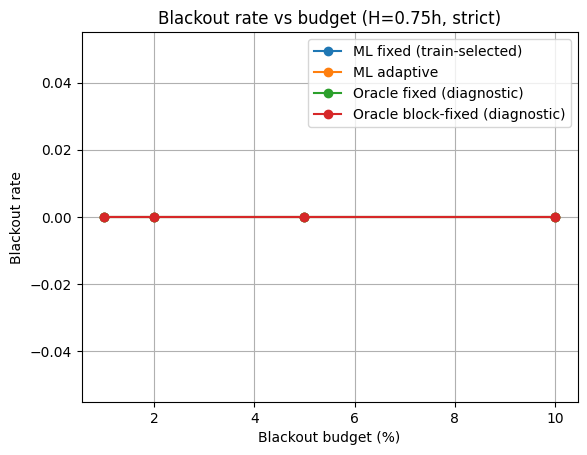

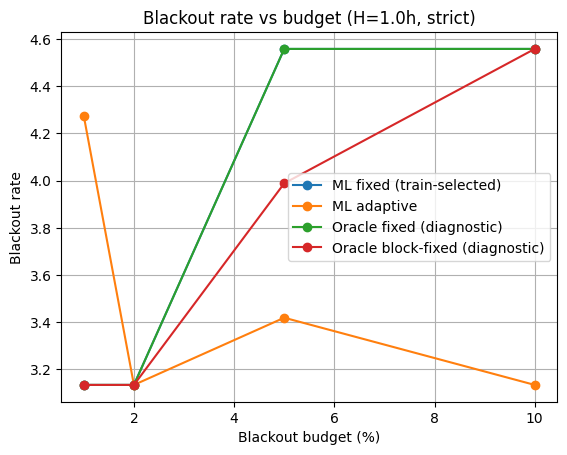

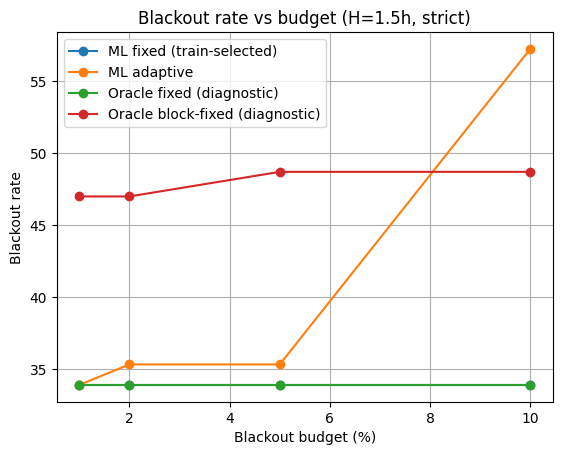

No rows for 1.0 relaxed_oracle
No rows for 1.5 relaxed_oracle


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

alpha0 = 0.20
buf0 = "fixed"

sub = df_run[(np.isclose(df_run["alpha"], alpha0)) &
             (df_run["buffer_mode"] == buf0) &
             (df_run["Budget"].notna())].copy()

deployable = ["ML fixed (train-selected)", "ML adaptive"]
oracles = ["Oracle fixed (diagnostic)", "Oracle block-fixed (diagnostic)"]

def plot_br_vs_budget(H, scenario):
    s = sub[(np.isclose(sub["Night_h"], H)) & (sub["Scenario"] == scenario)].copy()
    if s.empty:
        print("No rows for", H, scenario)
        return
    plt.figure()
    for pol in [p for p in deployable + oracles if p in s["Policy"].unique()]:
        t = s[s["Policy"] == pol].sort_values("Budget")
        plt.plot(t["Budget"], t["blackout_rate"], marker="o", label=pol)
    plt.title(f"Blackout rate vs budget (H={H}h, {scenario})")
    plt.xlabel("Blackout budget (%)")
    plt.ylabel("Blackout rate")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_br_vs_budget(0.75, "strict")
plot_br_vs_budget(1.00, "strict")
plot_br_vs_budget(1.50, "strict")

# these will only show once you re-add relaxed scenarios
plot_br_vs_budget(1.00, "relaxed_oracle")
plot_br_vs_budget(1.50, "relaxed_oracle")

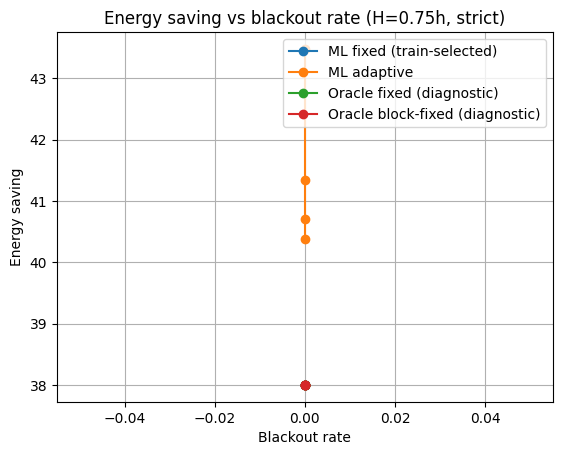

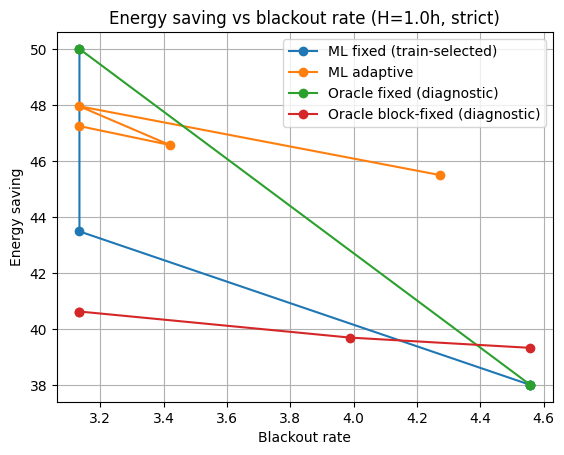

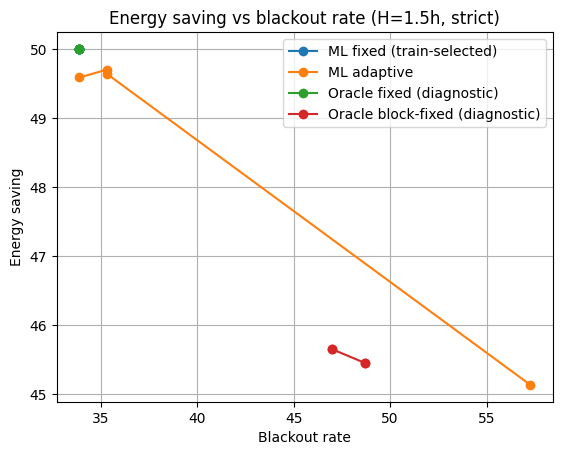

No rows for 1.0 relaxed_oracle
No rows for 1.5 relaxed_oracle


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

alpha0 = 0.20
buf0 = "fixed"

sub = df_run[(np.isclose(df_run["alpha"], alpha0)) &
             (df_run["buffer_mode"] == buf0) &
             (df_run["Budget"].notna())].copy()

deployable = ["ML fixed (train-selected)", "ML adaptive"]
oracles = ["Oracle fixed (diagnostic)", "Oracle block-fixed (diagnostic)"]

def plot_tradeoff(H, scenario):
    s = sub[(np.isclose(sub["Night_h"], H)) & (sub["Scenario"] == scenario)].copy()
    if s.empty:
        print("No rows for", H, scenario)
        return
    plt.figure()
    for pol in [p for p in deployable + oracles if p in s["Policy"].unique()]:
        t = s[s["Policy"] == pol].sort_values("Budget")
        plt.plot(t["blackout_rate"], t["energy_saving"], marker="o", label=pol)
    plt.title(f"Energy saving vs blackout rate (H={H}h, {scenario})")
    plt.xlabel("Blackout rate")
    plt.ylabel("Energy saving")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_tradeoff(0.75, "strict")
plot_tradeoff(1.00, "strict")
plot_tradeoff(1.50, "strict")

plot_tradeoff(1.00, "relaxed_oracle")
plot_tradeoff(1.50, "relaxed_oracle")

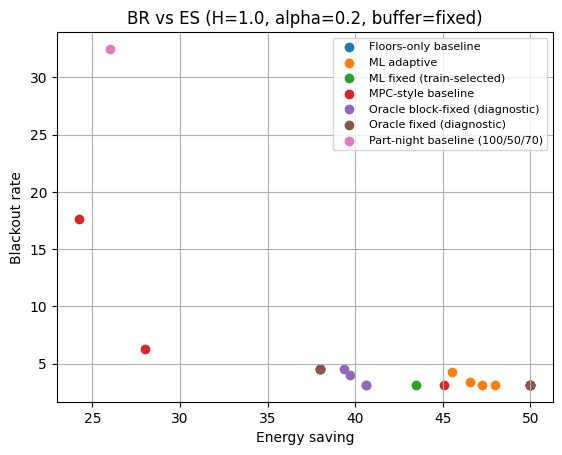

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

alpha0 = 0.20
buf0 = "fixed"
H_SHOW = 1.0

d = df_run[
    ((df_run["buffer_mode"] == "baseline") |
     ((df_run["buffer_mode"] == buf0) & np.isclose(df_run["alpha"], alpha0)))
].copy()

d = d[np.isclose(d["Night_h"], H_SHOW)].copy()

plt.figure()
for pol in sorted(d["Policy"].unique()):
    t = d[d["Policy"] == pol]
    plt.scatter(t["energy_saving"], t["blackout_rate"], label=pol)

plt.title(f"BR vs ES (H={H_SHOW}, alpha={alpha0}, buffer={buf0})")
plt.xlabel("Energy saving")
plt.ylabel("Blackout rate")
plt.grid(True)
plt.legend(fontsize=8)
plt.show()

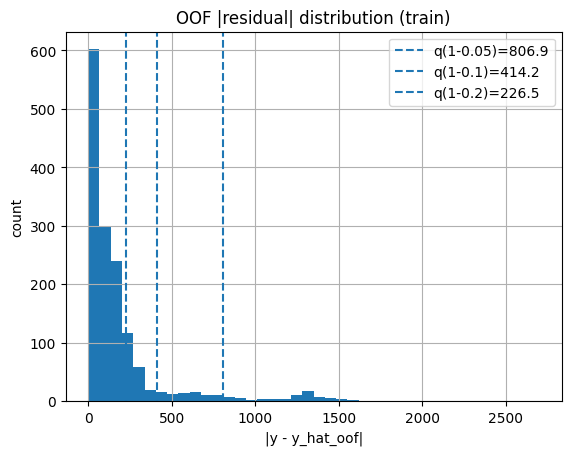

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

assert "art" in globals(), "art not found. Run Cell 5 first."

resid = art["resid"]

plt.figure()
plt.hist(resid, bins=40)
for a in [0.05, 0.10, 0.20]:
    q = float(np.quantile(resid, 1.0-a))
    plt.axvline(q, linestyle="--", label=f"q(1-{a})={q:.1f}")

plt.title("OOF |residual| distribution (train)")
plt.xlabel("|y - y_hat_oof|")
plt.ylabel("count")
plt.legend()
plt.grid(True)
plt.show()

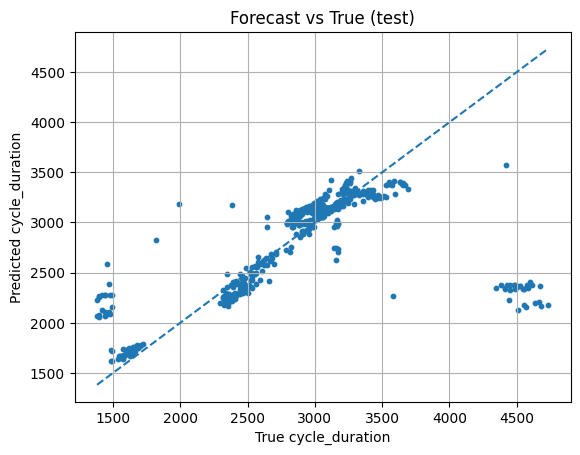

In [ ]:
import matplotlib.pyplot as plt

assert "art" in globals(), "art not found. Run Cell 5 first."

plt.figure()
plt.scatter(art["y_true"], art["y_hat"], s=10)
plt.plot([art["y_true"].min(), art["y_true"].max()],
         [art["y_true"].min(), art["y_true"].max()], linestyle="--")
plt.title("Forecast vs True (test)")
plt.xlabel("True cycle_duration")
plt.ylabel("Predicted cycle_duration")
plt.grid(True)
plt.show()

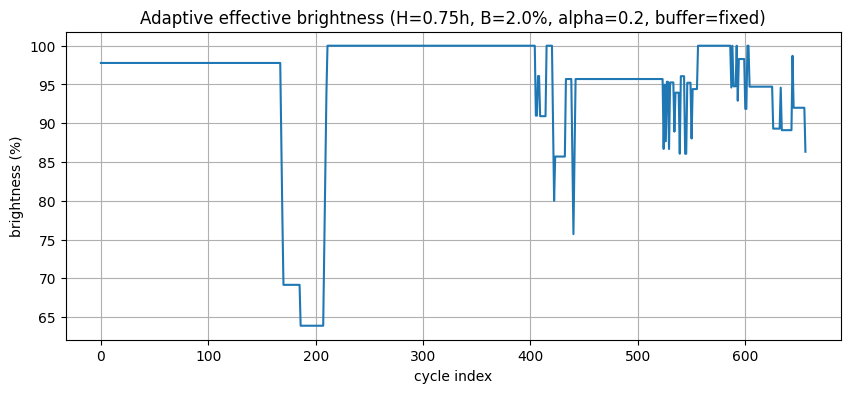

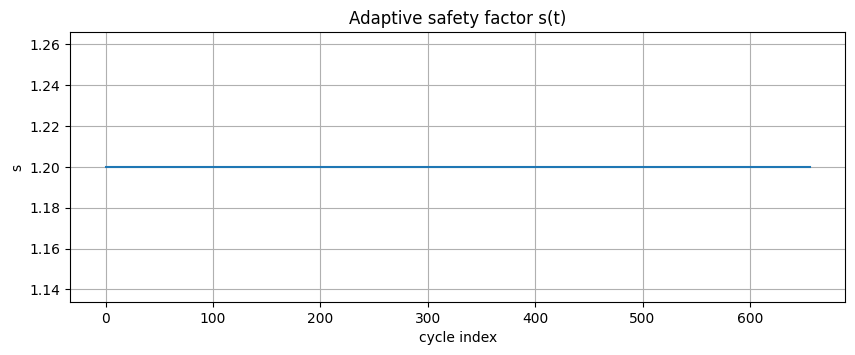

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

assert "art" in globals(), "art not found. Run Cell 5 first."

MAIN_ALPHA = 0.20
MAIN_BUFFER = "fixed"
H_demo = float(NIGHTS_H[0])
B_demo = float(BUDGETS[0])
T_demo = H_demo * 3600.0

q_alpha = float(np.quantile(art["resid"], 1.0 - MAIN_ALPHA))
qbuf = 0.0 if MAIN_BUFFER == "none" else q_alpha

y_true = art["y_true"]
y_hat  = art["y_hat"]

n = len(y_true)
s = float(SAFETY_INIT)
s_hist = np.zeros(n, float)
pct_avg = np.zeros(n, float)

for t in range(n):
    pct_avg[t] = ml_pct_from_forecast(
        np.array([y_hat[t]]), T_demo, s, qbuf, PHASE_FLOORS, PHASE_SPLIT
    )[0]
    start = max(0, t - ADAPT_WINDOW + 1)
    br_recent = float(np.mean(y_true[start:t+1] < T_demo))
    s = s + ADAPT_KP * (B_demo - br_recent)
    s = float(np.clip(s, S_MIN, S_MAX))
    s_hist[t] = s

pct_avg = apply_hysteresis_and_ramp(pct_avg, HYSTERESIS, RAMP_LIMIT)
_, _, _, pct_eff, _ = avg_to_phase_arrays(pct_avg, PHASE_FLOORS, PHASE_SPLIT, PRIORITY)

plt.figure(figsize=(10,4))
plt.plot(pct_eff)
plt.title(f"Adaptive effective brightness (H={H_demo}h, B={B_demo}%, alpha={MAIN_ALPHA}, buffer={MAIN_BUFFER})")
plt.xlabel("cycle index"); plt.ylabel("brightness (%)")
plt.grid(True); plt.show()

plt.figure(figsize=(10,3.5))
plt.plot(s_hist)
plt.title("Adaptive safety factor s(t)")
plt.xlabel("cycle index"); plt.ylabel("s")
plt.grid(True); plt.show()

In [ ]:
print(trade_master["mode"].unique())
print(trade_master["protocol"].value_counts())
print(trade_master["split_seed"].nunique(), trade_master["model_seed"].nunique())
print(trade_master["buffer_mode"].value_counts())

['review_fast']
protocol
standard    3660
Name: count, dtype: int64
5 2
buffer_mode
none        1800
fixed       1800
baseline      60
Name: count, dtype: int64


In [ ]:
art = fit_predict(df_train, df_test, model_name=model_name, model_seed=model_seed)

In [ ]:
import joblib, os, time
model = art.get("model", None) or art.get("estimator", None)
print("Model key candidates:", [k for k in art.keys() if "model" in k.lower() or "est" in k.lower()])
assert model is not None, "Could not find trained model in art dict"

Model key candidates: ['model', 'best_params']


In [ ]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np, time, os, joblib

# use the df_train/df_test from the same split you just ran
X_train = df_train[FEATURES].to_numpy()
y_train = df_train[TARGET].to_numpy().astype(float)
X_test  = df_test[FEATURES].to_numpy()

final = RandomForestRegressor(
    random_state=model_seed,  # use the same seed you ran
    n_jobs=-1,
    **art["best_params"]
)
final.fit(X_train, y_train)

joblib.dump(final, "rf.joblib")
print("Model size (KB):", os.path.getsize("rf.joblib")/1024)

Xs = X_test[:min(2000, len(X_test))]
t0 = time.perf_counter()
_ = final.predict(Xs)
t1 = time.perf_counter()
print("Avg predict time per sample (ms):", (t1 - t0) / len(Xs) * 1000)

Model size (KB): 51308.1572265625
Avg predict time per sample (ms): 0.22933208980314757


In [ ]:
from google.colab import files

files.download("robust_summary.csv")
files.download("trade_master.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# reviewers testing

In [ ]:
# ==========================================================
# LEAN REVIEW RUNNER
# For:
# R1 Major Comment 3: no-buffer vs fixed-buffer ablation
# R2 Major Comment 10: UM|BO p75 / p90 / p95 sensitivity
#
# Much faster than the previous Cell A.
# ==========================================================

import numpy as np
import pandas as pd
from pathlib import Path
from time import time

REVIEW_OUTDIR = Path("review_validation_outputs")
REVIEW_OUTDIR.mkdir(exist_ok=True)

REVIEW_MODE = "review_lean"

# Use [0, 1, 2] first. If you have time later, expand to [0,1,2,3,4].
REVIEW_SPLIT_SEEDS = [0, 1, 2]
REVIEW_MODEL_SEEDS = [0]

REVIEW_PROTOCOLS = ["standard"]
REVIEW_MODELS = ["rf"]

REVIEW_ALPHAS = [0.20]
REVIEW_BUFFER_MODES = ["none", "fixed"]

# Use manuscript budgets only to save time.
REVIEW_BUDGETS = [2, 5, 10]
REVIEW_HORIZONS = NIGHTS_H

REVIEW_POLICIES = [
    "ML fixed (train-selected)",
    "ML adaptive",
]

def _severity_from_metric_dict(m):
    blackout = np.asarray(m.get("blackout_mask", []), dtype=bool)
    unmet = np.asarray(m.get("unmet_minutes_per_night", []), dtype=float)

    if len(unmet) > 0 and len(blackout) == len(unmet):
        vals = unmet[blackout & (unmet > 0)]
    else:
        vals = np.array([], dtype=float)

    if len(vals) == 0:
        return {
            "unmet_minutes_blackout_p50": 0.0,
            "unmet_minutes_blackout_p75": 0.0,
            "unmet_minutes_blackout_p90": float(m.get("unmet_minutes_blackout_p90", 0.0)),
            "unmet_minutes_blackout_p95": 0.0,
        }

    return {
        "unmet_minutes_blackout_p50": float(np.percentile(vals, 50)),
        "unmet_minutes_blackout_p75": float(np.percentile(vals, 75)),
        "unmet_minutes_blackout_p90": float(np.percentile(vals, 90)),
        "unmet_minutes_blackout_p95": float(np.percentile(vals, 95)),
    }


def _metric_columns(m):
    sev = _severity_from_metric_dict(m)

    return {
        "blackout_rate": float(m["blackout_rate"]),
        "energy_saving": float(m["energy_saving"]),
        "unmet_minutes_blackout": float(m.get("unmet_minutes_blackout", np.nan)),
        "unmet_minutes_blackout_p50": sev["unmet_minutes_blackout_p50"],
        "unmet_minutes_blackout_p75": sev["unmet_minutes_blackout_p75"],
        "unmet_minutes_blackout_p90": sev["unmet_minutes_blackout_p90"],
        "unmet_minutes_blackout_p95": sev["unmet_minutes_blackout_p95"],
        "unmet_minutes_all_mean": float(m.get("unmet_minutes_all_mean", np.nan)),
    }


def _make_result_row(
    exp_tag,
    H,
    budget,
    scenario,
    policy,
    alpha,
    buffer_mode,
    metrics,
    safety=np.nan,
):
    row = {
        "exp_tag": exp_tag,
        "Night_h": float(H),
        "Budget": np.nan if budget is None else float(budget),
        "Scenario": scenario,
        "Policy": policy,
        "alpha": np.nan if alpha is None else float(alpha),
        "buffer_mode": buffer_mode,
        "Safety": safety,
    }

    row.update(_metric_columns(metrics))
    return row


def run_defensible_sweep_review_lean(art, exp_tag="review_lean_run"):
    y_train = art["y_train"]
    oof = art["oof"]
    resid = art["resid"]
    y_true = art["y_true"]
    y_hat = art["y_hat"]

    rows = []

    for alpha in REVIEW_ALPHAS:
        alpha = float(alpha)
        q_alpha = float(np.quantile(resid, 1.0 - alpha))

        for buffer_mode in REVIEW_BUFFER_MODES:
            buffer_mode = str(buffer_mode).lower()
            qbuf = 0.0 if buffer_mode == "none" else q_alpha

            for H in REVIEW_HORIZONS:
                T = float(H) * 3600.0

                for bud in REVIEW_BUDGETS:
                    bud = float(bud)

                    # --------------------------
                    # ML fixed
                    # --------------------------
                    s_star, _, _ = choose_fixed_safety(
                        y_train,
                        oof,
                        T,
                        qbuf,
                        PHASE_FLOORS,
                        PHASE_SPLIT,
                        budget=bud,
                        s_grid=S_GRID,
                    )

                    pct = ml_pct_from_forecast(
                        y_hat,
                        T,
                        s_star,
                        qbuf,
                        PHASE_FLOORS,
                        PHASE_SPLIT,
                    )

                    pct = apply_hysteresis_and_ramp(
                        pct,
                        HYSTERESIS,
                        RAMP_LIMIT,
                    )

                    m_fixed = simulate_metrics_from_pct_eff(
                        pct_eff=pct,
                        T=T,
                        y_true=y_true,
                        floors=PHASE_FLOORS,
                        split=PHASE_SPLIT,
                        priority=PRIORITY,
                    )

                    rows.append(
                        _make_result_row(
                            exp_tag=exp_tag,
                            H=H,
                            budget=bud,
                            scenario="strict",
                            policy="ML fixed (train-selected)",
                            alpha=alpha,
                            buffer_mode=buffer_mode,
                            metrics=m_fixed,
                            safety=float(s_star),
                        )
                    )

                    # --------------------------
                    # ML adaptive
                    # --------------------------
                    s_hist, pct_eff_adapt, m_adapt, dbg = adaptive_controller_exp(
                        y_true=y_true,
                        y_hat=y_hat,
                        T=T,
                        qbuf=qbuf,
                        floors=PHASE_FLOORS,
                        split=PHASE_SPLIT,
                        budget=bud,
                        window=ADAPT_WINDOW,
                        kappa=0.02,
                        s_init=SAFETY_INIT,
                        hysteresis=HYSTERESIS,
                        ramp_limit=RAMP_LIMIT,
                        s_min=S_MIN,
                        s_max=S_MAX,
                    )

                    rows.append(
                        _make_result_row(
                            exp_tag=exp_tag,
                            H=H,
                            budget=bud,
                            scenario="strict",
                            policy="ML adaptive",
                            alpha=alpha,
                            buffer_mode=buffer_mode,
                            metrics=m_adapt,
                            safety=np.nan,
                        )
                    )

    return pd.DataFrame(rows)


# ==========================================================
# Execute lean review run
# ==========================================================

start = time()
all_review_trades = []

print("Starting LEAN review run...")
print("Protocols:", REVIEW_PROTOCOLS)
print("Split seeds:", REVIEW_SPLIT_SEEDS)
print("Model seeds:", REVIEW_MODEL_SEEDS)
print("Models:", REVIEW_MODELS)
print("Alphas:", REVIEW_ALPHAS)
print("Buffer modes:", REVIEW_BUFFER_MODES)
print("Budgets:", REVIEW_BUDGETS)
print("Policies:", REVIEW_POLICIES)

for protocol in REVIEW_PROTOCOLS:
    for split_seed in REVIEW_SPLIT_SEEDS:
        df_train_i, df_test_i = make_split(
            df0,
            split_seed=split_seed,
            use_iqr=USE_IQR_CLEANING,
            protocol=protocol,
            early_frac=SHIFT_EARLY_FRAC,
            late_frac=SHIFT_LATE_FRAC,
            min_cycles=SHIFT_MIN_CYCLES,
            order_col=SHIFT_ORDER_COL,
        )

        for model_seed in REVIEW_MODEL_SEEDS:
            for model_name in REVIEW_MODELS:
                exp_tag = (
                    f"{REVIEW_MODE}_{protocol}_split{split_seed}_"
                    f"{model_name}_seed{model_seed}_iqr{int(USE_IQR_CLEANING)}"
                )

                print("Running:", exp_tag)

                art_i = fit_predict(
                    df_train_i,
                    df_test_i,
                    model_name=model_name,
                    model_seed=model_seed,
                )

                trade_i = run_defensible_sweep_review_lean(
                    art_i,
                    exp_tag=exp_tag,
                )

                trade_i["mode"] = REVIEW_MODE
                trade_i["protocol"] = protocol
                trade_i["split_seed"] = split_seed
                trade_i["model_seed"] = model_seed
                trade_i["model"] = model_name
                trade_i["use_iqr"] = bool(USE_IQR_CLEANING)
                trade_i["shift_early_frac"] = SHIFT_EARLY_FRAC if protocol == "aging_shift" else np.nan
                trade_i["shift_late_frac"] = SHIFT_LATE_FRAC if protocol == "aging_shift" else np.nan

                all_review_trades.append(trade_i)

trade_master_review = pd.concat(all_review_trades, ignore_index=True)

out_csv = REVIEW_OUTDIR / "trade_master_review.csv"
trade_master_review.to_csv(out_csv, index=False)

elapsed_min = (time() - start) / 60.0

print("\nSaved:", out_csv)
print("Rows:", len(trade_master_review))
print("Elapsed minutes:", round(elapsed_min, 2))
print("Columns:", list(trade_master_review.columns))
display(trade_master_review.head(12))

Starting LEAN review run...
Protocols: ['standard']
Split seeds: [0, 1, 2]
Model seeds: [0]
Models: ['rf']
Alphas: [0.2]
Buffer modes: ['none', 'fixed']
Budgets: [2, 5, 10]
Policies: ['ML fixed (train-selected)', 'ML adaptive']
[standard | split 0] IQR bounds: [1697.546, 4308.298] | train 1475/2140 | test 351/654
Running: review_lean_standard_split0_rf_seed0_iqr1
[standard | split 1] IQR bounds: [1101.477, 4763.789] | train 1533/1945 | test 631/849
Running: review_lean_standard_split1_rf_seed0_iqr1
[standard | split 2] IQR bounds: [0.000, 7829.309] | train 1683/1683 | test 1111/1111
Running: review_lean_standard_split2_rf_seed0_iqr1

Saved: review_validation_outputs/trade_master_review.csv
Rows: 108
Elapsed minutes: 37.9
Columns: ['exp_tag', 'Night_h', 'Budget', 'Scenario', 'Policy', 'alpha', 'buffer_mode', 'Safety', 'blackout_rate', 'energy_saving', 'unmet_minutes_blackout', 'unmet_minutes_blackout_p50', 'unmet_minutes_blackout_p75', 'unmet_minutes_blackout_p90', 'unmet_minutes_blacko

,exp_tag,Night_h,Budget,Scenario,Policy,alpha,buffer_mode,Safety,blackout_rate,energy_saving,...,unmet_minutes_blackout_p95,unmet_minutes_all_mean,mode,protocol,split_seed,model_seed,model,use_iqr,shift_early_frac,shift_late_frac
0,review_lean_standard_split0_rf_seed0_iqr1,0.75,2.0,strict,ML fixed (train-selected),0.2,none,1.200,0.000000,38.000000,...,0.000000,0.000000,review_lean,standard,0,0,rf,True,NaN,NaN
1,review_lean_standard_split0_rf_seed0_iqr1,0.75,2.0,strict,ML adaptive,0.2,none,NaN,0.000000,41.899840,...,0.000000,0.000000,review_lean,standard,0,0,rf,True,NaN,NaN
2,review_lean_standard_split0_rf_seed0_iqr1,0.75,5.0,strict,ML fixed (train-selected),0.2,none,1.200,0.000000,38.000000,...,0.000000,0.000000,review_lean,standard,0,0,rf,True,NaN,NaN
3,review_lean_standard_split0_rf_seed0_iqr1,0.75,5.0,strict,ML adaptive,0.2,none,NaN,0.000000,41.045784,...,0.000000,0.000000,review_lean,standard,0,0,rf,True,NaN,NaN
4,review_lean_standard_split0_rf_seed0_iqr1,0.75,10.0,strict,ML fixed (train-selected),0.2,none,1.200,0.000000,38.000000,...,0.000000,0.000000,review_lean,standard,0,0,rf,True,NaN,NaN
5,review_lean_standard_split0_rf_seed0_iqr1,0.75,10.0,strict,ML adaptive,0.2,none,NaN,0.000000,40.956029,...,0.000000,0.000000,review_lean,standard,0,0,rf,True,NaN,NaN
6,review_lean_standard_split0_rf_seed0_iqr1,1.00,2.0,strict,ML fixed (train-selected),0.2,none,0.695,3.133903,43.547852,...,3.410400,0.080392,review_lean,standard,0,0,rf,True,NaN,NaN
7,review_lean_standard_split0_rf_seed0_iqr1,1.00,2.0,strict,ML adaptive,0.2,none,NaN,3.418803,47.783817,...,5.064638,0.136907,review_lean,standard,0,0,rf,True,NaN,NaN
8,review_lean_standard_split0_rf_seed0_iqr1,1.00,5.0,strict,ML fixed (train-selected),0.2,none,1.200,4.558405,38.016376,...,21.341583,0.762229,review_lean,standard,0,0,rf,True,NaN,NaN
9,review_lean_standard_split0_rf_seed0_iqr1,1.00,5.0,strict,ML adaptive,0.2,none,NaN,3.418803,47.052654,...,6.247029,0.177331,review_lean,standard,0,0,rf,True,NaN,NaN


Rows used: 108
Buffer modes: {'none': 54, 'fixed': 54}
Replicates: 3


,Night_h,Budget,Policy,n_pairs,blackout_rate_none_mean,blackout_rate_fixed_mean,blackout_rate_delta_mean,blackout_rate_delta_ci95_low,blackout_rate_delta_ci95_high,blackout_rate_delta_ci95_half_width,...,energy_saving_paired_t_p,energy_saving_wilcoxon_p,unmet_minutes_blackout_p90_none_mean,unmet_minutes_blackout_p90_fixed_mean,unmet_minutes_blackout_p90_delta_mean,unmet_minutes_blackout_p90_delta_ci95_low,unmet_minutes_blackout_p90_delta_ci95_high,unmet_minutes_blackout_p90_delta_ci95_half_width,unmet_minutes_blackout_p90_paired_t_p,unmet_minutes_blackout_p90_wilcoxon_p
0,0.75,2.0,ML adaptive,3,1.560156,1.470147,-0.090009,-0.477286,0.297268,0.387277,...,0.931556,1.00,14.257639,14.134200,-0.123439,-0.654557,0.407678,0.531117,0.422650,1.00
1,0.75,2.0,ML fixed (train-selected),3,1.545796,1.545796,0.000000,0.000000,0.000000,0.000000,...,0.422650,1.00,14.775430,14.775430,0.000000,0.000000,0.000000,0.000000,NaN,1.00
2,0.75,5.0,ML adaptive,3,1.762997,1.522973,-0.240024,-1.272764,0.792716,1.032740,...,0.109938,0.25,14.682706,14.500690,-0.182016,-0.575170,0.211137,0.393153,0.184599,0.50
3,0.75,5.0,ML fixed (train-selected),3,1.651449,1.651449,0.000000,0.000000,0.000000,0.000000,...,NaN,1.00,14.796368,14.796368,0.000000,0.000000,0.000000,0.000000,NaN,1.00
4,0.75,10.0,ML adaptive,3,2.115853,1.575799,-0.540054,-2.863719,1.783611,2.323665,...,0.621742,0.75,14.170091,14.775418,0.605327,-1.999185,3.209839,2.604512,0.422650,1.00
5,0.75,10.0,ML fixed (train-selected),3,1.741458,1.741458,0.000000,0.000000,0.000000,0.000000,...,0.422650,1.00,14.796330,14.921362,0.125032,-0.412937,0.663001,0.537969,0.422650,1.00
6,1.00,2.0,ML adaptive,3,5.143599,4.958623,-0.184976,-0.583348,0.213396,0.398372,...,0.095581,0.25,20.233789,18.483751,-1.750038,-4.616808,1.116731,2.866769,0.119515,0.25
7,1.00,2.0,ML fixed (train-selected),3,4.770142,4.770142,0.000000,0.000000,0.000000,0.000000,...,0.422650,1.00,18.388846,18.388846,0.000000,0.000000,0.000000,0.000000,NaN,1.00
8,1.00,5.0,ML adaptive,3,5.302078,5.113596,-0.188482,-0.815855,0.438892,0.627374,...,0.926769,1.00,22.887076,19.650040,-3.237036,-15.592530,9.118458,12.355494,0.376692,0.50
9,1.00,5.0,ML fixed (train-selected),3,5.244975,5.244975,0.000000,0.000000,0.000000,0.000000,...,0.422650,1.00,24.300509,24.300509,0.000000,0.000000,0.000000,0.000000,NaN,1.00


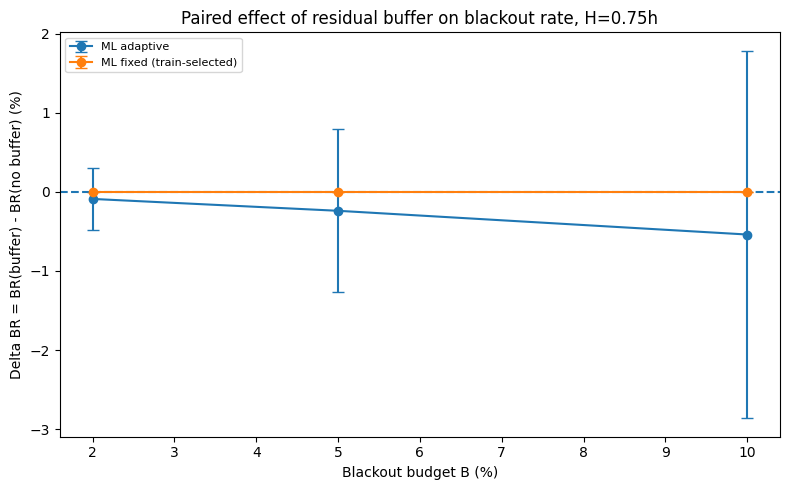

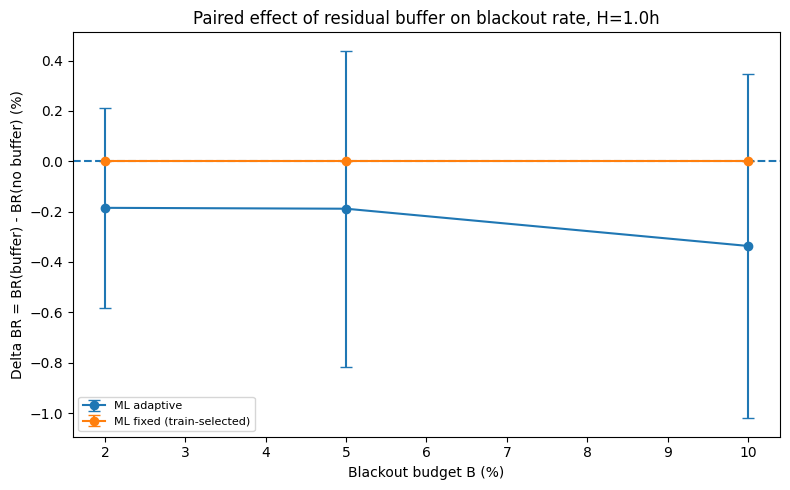

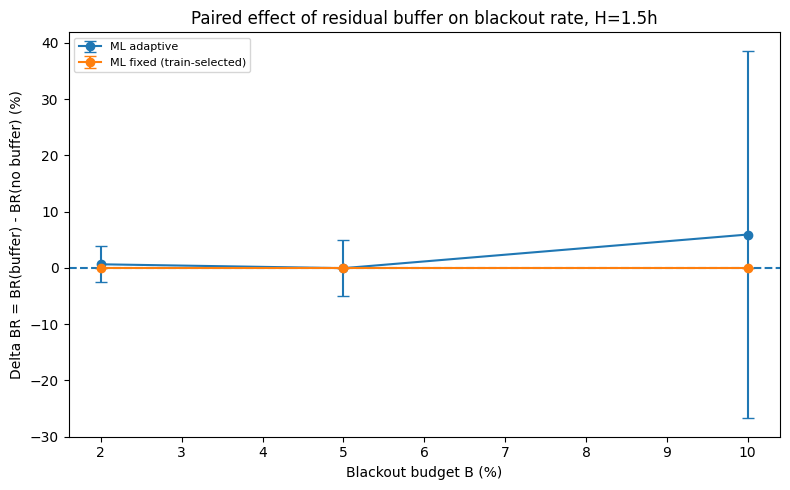

Saved R1 Major 3 outputs to: /content/review_validation_outputs/R1_major3_buffer_ablation


In [ ]:
# ==========================================================
# R1 Major Comment 3:
# Controlled ablation of residual-quantile buffer
# Compare no buffer vs fixed residual-quantile buffer
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

try:
    from scipy.stats import ttest_1samp, wilcoxon, t
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

OUTDIR = Path("review_validation_outputs/R1_major3_buffer_ablation")
OUTDIR.mkdir(parents=True, exist_ok=True)

if "trade_master_review" in globals():
    df0_review = trade_master_review.copy()
else:
    df0_review = pd.read_csv("review_validation_outputs/trade_master_review.csv")

MAIN_PROTOCOL = "standard"
MAIN_MODEL = "rf"
MAIN_ALPHA = 0.20
MAIN_SCENARIO = "strict"

POLICIES_TO_REPORT = [
    "ML fixed (train-selected)",
    "ML adaptive",
]

METRICS = [
    "blackout_rate",
    "energy_saving",
    "unmet_minutes_blackout_p90",
]

df = df0_review.copy()

df = df[
    (df["protocol"] == MAIN_PROTOCOL) &
    (df["model"] == MAIN_MODEL) &
    (df["Scenario"] == MAIN_SCENARIO) &
    (df["Policy"].isin(POLICIES_TO_REPORT)) &
    (df["Budget"].notna()) &
    (np.isclose(df["alpha"], MAIN_ALPHA))
].copy()

if df.empty:
    raise ValueError(
        "No rows after filtering. Check protocol/model/scenario/policies/alpha settings."
    )

df["replicate_id"] = (
    df["split_seed"].astype(str) + "_" +
    df["model_seed"].astype(str)
)

print("Rows used:", len(df))
print("Buffer modes:", df["buffer_mode"].value_counts().to_dict())
print("Replicates:", df["replicate_id"].nunique())

pair_cols = [
    "protocol",
    "model",
    "replicate_id",
    "split_seed",
    "model_seed",
    "Night_h",
    "Budget",
    "Policy",
]

none_df = df[df["buffer_mode"] == "none"].copy()
fixed_df = df[df["buffer_mode"] == "fixed"].copy()

none_df = none_df[pair_cols + METRICS].rename(columns={
    "blackout_rate": "blackout_rate_none",
    "energy_saving": "energy_saving_none",
    "unmet_minutes_blackout_p90": "unmet_minutes_blackout_p90_none",
})

fixed_df = fixed_df[pair_cols + METRICS].rename(columns={
    "blackout_rate": "blackout_rate_fixed",
    "energy_saving": "energy_saving_fixed",
    "unmet_minutes_blackout_p90": "unmet_minutes_blackout_p90_fixed",
})

paired = fixed_df.merge(
    none_df,
    on=pair_cols,
    how="inner",
)

paired["delta_blackout_rate"] = (
    paired["blackout_rate_fixed"] - paired["blackout_rate_none"]
)

paired["delta_energy_saving"] = (
    paired["energy_saving_fixed"] - paired["energy_saving_none"]
)

paired["delta_unmet_minutes_blackout_p90"] = (
    paired["unmet_minutes_blackout_p90_fixed"] -
    paired["unmet_minutes_blackout_p90_none"]
)

paired.to_csv(
    OUTDIR / "raw_paired_buffer_vs_no_buffer_alpha020.csv",
    index=False,
)

def ci95(x):
    x = pd.Series(x).dropna().astype(float)
    n = len(x)

    if n == 0:
        return np.nan, np.nan, np.nan, np.nan, 0

    mean = float(x.mean())
    std = float(x.std(ddof=1)) if n > 1 else 0.0

    if n > 1:
        crit = float(t.ppf(0.975, df=n - 1)) if SCIPY_AVAILABLE else 1.96
        half_width = crit * std / np.sqrt(n)
    else:
        half_width = 0.0

    return mean, mean - half_width, mean + half_width, half_width, n


def pvalues_delta(x):
    x = pd.Series(x).dropna().astype(float)

    if len(x) < 2 or not SCIPY_AVAILABLE:
        return np.nan, np.nan

    try:
        p_t = float(ttest_1samp(x, popmean=0.0).pvalue)
    except Exception:
        p_t = np.nan

    try:
        if np.allclose(x, 0):
            p_w = 1.0
        else:
            p_w = float(wilcoxon(x).pvalue)
    except Exception:
        p_w = np.nan

    return p_t, p_w


rows = []

for keys, g in paired.groupby(["Night_h", "Budget", "Policy"], dropna=False):
    H, B, policy = keys

    row = {
        "Night_h": H,
        "Budget": B,
        "Policy": policy,
        "n_pairs": len(g),
    }

    for metric in [
        "blackout_rate",
        "energy_saving",
        "unmet_minutes_blackout_p90",
    ]:
        none_col = f"{metric}_none"
        fixed_col = f"{metric}_fixed"
        delta_col = f"delta_{metric}"

        none_mean, none_low, none_high, none_hw, _ = ci95(g[none_col])
        fixed_mean, fixed_low, fixed_high, fixed_hw, _ = ci95(g[fixed_col])
        delta_mean, delta_low, delta_high, delta_hw, _ = ci95(g[delta_col])
        p_t, p_w = pvalues_delta(g[delta_col])

        row[f"{metric}_none_mean"] = none_mean
        row[f"{metric}_fixed_mean"] = fixed_mean
        row[f"{metric}_delta_mean"] = delta_mean
        row[f"{metric}_delta_ci95_low"] = delta_low
        row[f"{metric}_delta_ci95_high"] = delta_high
        row[f"{metric}_delta_ci95_half_width"] = delta_hw
        row[f"{metric}_paired_t_p"] = p_t
        row[f"{metric}_wilcoxon_p"] = p_w

    rows.append(row)

buffer_ablation_table = pd.DataFrame(rows)

buffer_ablation_table.to_csv(
    OUTDIR / "table_R1_major3_buffer_ablation_paired_95CI_pvalues.csv",
    index=False,
)

display(buffer_ablation_table)

# Compact plot: delta BR = BR(buffer) - BR(no buffer)
# Negative values mean the buffer reduced blackout rate.
PLOT_POLICIES = [
    "ML fixed (train-selected)",
    "ML adaptive",
    "MPC-style baseline",
]

delta_plot = buffer_ablation_table[
    buffer_ablation_table["Policy"].isin(PLOT_POLICIES)
].copy()

for H in sorted(delta_plot["Night_h"].unique()):
    dH = delta_plot[np.isclose(delta_plot["Night_h"], H)].copy()

    plt.figure(figsize=(8, 5))

    for policy, g in dH.groupby("Policy"):
        g = g.sort_values("Budget")

        plt.errorbar(
            g["Budget"],
            g["blackout_rate_delta_mean"],
            yerr=g["blackout_rate_delta_ci95_half_width"],
            marker="o",
            capsize=4,
            label=policy,
        )

    plt.axhline(0, linestyle="--")
    plt.xlabel("Blackout budget B (%)")
    plt.ylabel("Delta BR = BR(buffer) - BR(no buffer) (%)")
    plt.title(f"Paired effect of residual buffer on blackout rate, H={H}h")
    plt.legend(fontsize=8)
    plt.tight_layout()

    out = OUTDIR / f"fig_R1_major3_delta_BR_buffer_minus_none_H{str(H).replace('.', '_')}.png"
    plt.savefig(out, dpi=300)
    plt.show()

print("Saved R1 Major 3 outputs to:", OUTDIR.resolve())

[standard | split 0] IQR bounds: [1697.546, 4308.298] | train 1475/2140 | test 351/654
Running: isolated_buffer_split0_rf_seed0
[standard | split 1] IQR bounds: [1101.477, 4763.789] | train 1533/1945 | test 631/849
Running: isolated_buffer_split1_rf_seed0
[standard | split 2] IQR bounds: [0.000, 7829.309] | train 1683/1683 | test 1111/1111
Running: isolated_buffer_split2_rf_seed0


,Night_h,Budget,Policy,n_pairs,blackout_rate_no_buffer_mean,blackout_rate_buffer_mean,blackout_rate_delta_mean,blackout_rate_delta_ci95_low,blackout_rate_delta_ci95_high,blackout_rate_delta_ci95_half_width,...,energy_saving_paired_t_p,energy_saving_wilcoxon_p,unmet_minutes_blackout_p90_no_buffer_mean,unmet_minutes_blackout_p90_buffer_mean,unmet_minutes_blackout_p90_delta_mean,unmet_minutes_blackout_p90_delta_ci95_low,unmet_minutes_blackout_p90_delta_ci95_high,unmet_minutes_blackout_p90_delta_ci95_half_width,unmet_minutes_blackout_p90_paired_t_p,unmet_minutes_blackout_p90_wilcoxon_p
0,0.75,2.0,ML fixed (same safety factor),3,1.545796,1.545796,0.000000,0.000000,0.000000,0.000000,...,0.42265,1.0,14.775430,14.580183,-0.195248,-1.035331,0.644836,0.840084,0.42265,1.0
1,0.75,5.0,ML fixed (same safety factor),3,1.651449,1.651449,0.000000,0.000000,0.000000,0.000000,...,NaN,1.0,14.796368,14.796368,0.000000,0.000000,0.000000,0.000000,NaN,1.0
2,0.75,10.0,ML fixed (same safety factor),3,1.741458,1.711455,-0.030003,-0.159095,0.099089,0.129092,...,0.42265,1.0,14.796330,14.796343,0.000013,-0.000042,0.000067,0.000055,0.42265,1.0
3,1.00,2.0,ML fixed (same safety factor),3,4.770142,4.770142,0.000000,0.000000,0.000000,0.000000,...,0.42265,1.0,18.388846,18.388846,0.000000,0.000000,0.000000,0.000000,NaN,1.0
4,1.00,5.0,ML fixed (same safety factor),3,5.244975,5.244975,0.000000,0.000000,0.000000,0.000000,...,0.42265,1.0,24.300509,24.300509,0.000000,0.000000,0.000000,0.000000,NaN,1.0
5,1.00,10.0,ML fixed (same safety factor),3,5.244975,5.244975,0.000000,0.000000,0.000000,0.000000,...,0.42265,1.0,24.300509,24.300509,0.000000,0.000000,0.000000,0.000000,NaN,1.0
6,1.50,2.0,ML fixed (same safety factor),3,24.696029,24.696029,0.000000,0.000000,0.000000,0.000000,...,NaN,1.0,46.603289,46.603289,0.000000,0.000000,0.000000,0.000000,NaN,1.0
7,1.50,5.0,ML fixed (same safety factor),3,24.696029,24.696029,0.000000,0.000000,0.000000,0.000000,...,NaN,1.0,46.603289,46.603289,0.000000,0.000000,0.000000,0.000000,NaN,1.0
8,1.50,10.0,ML fixed (same safety factor),3,24.696029,24.696029,0.000000,0.000000,0.000000,0.000000,...,NaN,1.0,46.603289,46.603289,0.000000,0.000000,0.000000,0.000000,NaN,1.0


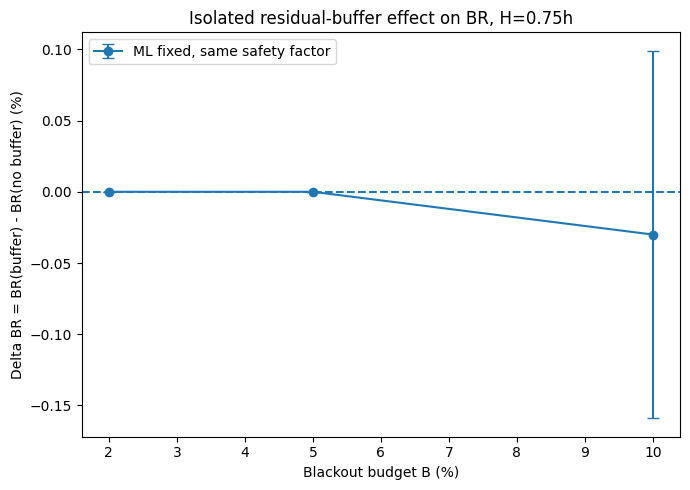

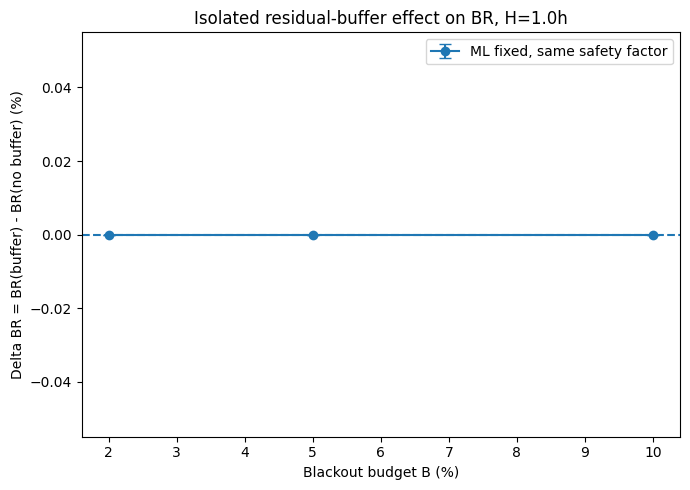

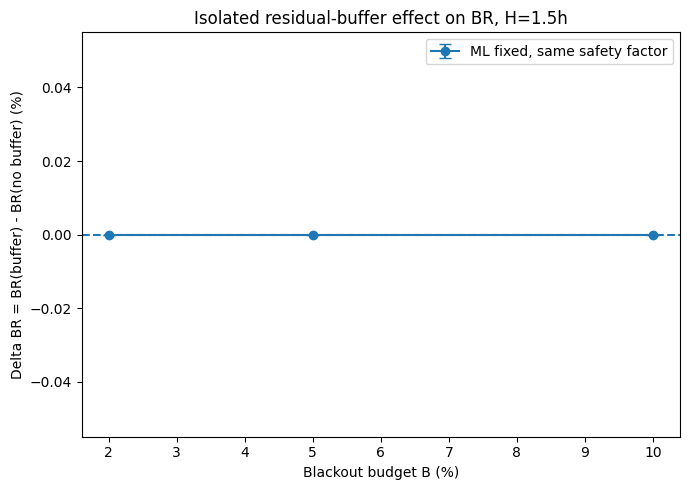

Saved isolated buffer-effect outputs to: /content/review_validation_outputs/R1_major3_isolated_buffer_effect


In [ ]:
# ==========================================================
# R1 Major Comment 3B:
# Isolated residual-buffer effect
# Same model, same split, same safety factor.
# Only qbuf changes: qbuf = 0 vs qbuf = residual quantile.
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

try:
    from scipy.stats import ttest_1samp, wilcoxon, t
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

OUTDIR = Path("review_validation_outputs/R1_major3_isolated_buffer_effect")
OUTDIR.mkdir(parents=True, exist_ok=True)

REVIEW_SPLIT_SEEDS_ISO = [0, 1, 2]      # for debug; use [0,1,2,3,4] for final
REVIEW_MODEL_SEEDS_ISO = [0]            # use [0,1] for final if time allows
REVIEW_ALPHA = 0.20
REVIEW_BUDGETS_ISO = [2, 5, 10]
REVIEW_HORIZONS_ISO = NIGHTS_H

def _severity_from_metric_dict_iso(m):
    blackout = np.asarray(m.get("blackout_mask", []), dtype=bool)
    unmet = np.asarray(m.get("unmet_minutes_per_night", []), dtype=float)

    if len(unmet) > 0 and len(blackout) == len(unmet):
        vals = unmet[blackout & (unmet > 0)]
    else:
        vals = np.array([], dtype=float)

    if len(vals) == 0:
        return {
            "unmet_minutes_blackout_p75": 0.0,
            "unmet_minutes_blackout_p90": float(m.get("unmet_minutes_blackout_p90", 0.0)),
            "unmet_minutes_blackout_p95": 0.0,
        }

    return {
        "unmet_minutes_blackout_p75": float(np.percentile(vals, 75)),
        "unmet_minutes_blackout_p90": float(np.percentile(vals, 90)),
        "unmet_minutes_blackout_p95": float(np.percentile(vals, 95)),
    }


def _metric_cols_iso(m):
    sev = _severity_from_metric_dict_iso(m)
    return {
        "blackout_rate": float(m["blackout_rate"]),
        "energy_saving": float(m["energy_saving"]),
        "unmet_minutes_blackout": float(m.get("unmet_minutes_blackout", np.nan)),
        "unmet_minutes_blackout_p75": sev["unmet_minutes_blackout_p75"],
        "unmet_minutes_blackout_p90": sev["unmet_minutes_blackout_p90"],
        "unmet_minutes_blackout_p95": sev["unmet_minutes_blackout_p95"],
        "unmet_minutes_all_mean": float(m.get("unmet_minutes_all_mean", np.nan)),
    }


def ci95(x):
    x = pd.Series(x).dropna().astype(float)
    n = len(x)

    if n == 0:
        return np.nan, np.nan, np.nan, np.nan, 0

    mean = float(x.mean())
    std = float(x.std(ddof=1)) if n > 1 else 0.0

    if n > 1:
        crit = float(t.ppf(0.975, df=n - 1)) if SCIPY_AVAILABLE else 1.96
        half_width = crit * std / np.sqrt(n)
    else:
        half_width = 0.0

    return mean, mean - half_width, mean + half_width, half_width, n


def pvalues_delta(x):
    x = pd.Series(x).dropna().astype(float)

    if len(x) < 2 or not SCIPY_AVAILABLE:
        return np.nan, np.nan

    try:
        p_t = float(ttest_1samp(x, popmean=0.0).pvalue)
    except Exception:
        p_t = np.nan

    try:
        if np.allclose(x, 0):
            p_w = 1.0
        else:
            p_w = float(wilcoxon(x).pvalue)
    except Exception:
        p_w = np.nan

    return p_t, p_w


rows = []

for split_seed in REVIEW_SPLIT_SEEDS_ISO:
    df_train_i, df_test_i = make_split(
        df0,
        split_seed=split_seed,
        use_iqr=USE_IQR_CLEANING,
        protocol="standard",
        early_frac=SHIFT_EARLY_FRAC,
        late_frac=SHIFT_LATE_FRAC,
        min_cycles=SHIFT_MIN_CYCLES,
        order_col=SHIFT_ORDER_COL,
    )

    for model_seed in REVIEW_MODEL_SEEDS_ISO:
        exp_tag = f"isolated_buffer_split{split_seed}_rf_seed{model_seed}"

        print("Running:", exp_tag)

        art = fit_predict(
            df_train_i,
            df_test_i,
            model_name="rf",
            model_seed=model_seed,
        )

        y_train = art["y_train"]
        oof = art["oof"]
        resid = art["resid"]
        y_true = art["y_true"]
        y_hat = art["y_hat"]

        qbuf_fixed = float(np.quantile(resid, 1.0 - REVIEW_ALPHA))
        qbuf_none = 0.0

        for H in REVIEW_HORIZONS_ISO:
            T = float(H) * 3600.0

            for bud in REVIEW_BUDGETS_ISO:
                bud = float(bud)

                # ------------------------------------------------------
                # Key design choice:
                # Select safety factor ONCE using no-buffer OOF.
                # Then evaluate the same s_star with qbuf=0 and qbuf=q.
                # This isolates the residual buffer effect.
                # ------------------------------------------------------
                s_star, _, _ = choose_fixed_safety(
                    y_train,
                    oof,
                    T,
                    qbuf_none,
                    PHASE_FLOORS,
                    PHASE_SPLIT,
                    budget=bud,
                    s_grid=S_GRID,
                )

                for label, qbuf in [
                    ("no_buffer_same_s", qbuf_none),
                    ("buffer_same_s", qbuf_fixed),
                ]:
                    pct = ml_pct_from_forecast(
                        y_hat,
                        T,
                        s_star,
                        qbuf,
                        PHASE_FLOORS,
                        PHASE_SPLIT,
                    )

                    pct = apply_hysteresis_and_ramp(
                        pct,
                        HYSTERESIS,
                        RAMP_LIMIT,
                    )

                    m = simulate_metrics_from_pct_eff(
                        pct_eff=pct,
                        T=T,
                        y_true=y_true,
                        floors=PHASE_FLOORS,
                        split=PHASE_SPLIT,
                        priority=PRIORITY,
                    )

                    row = {
                        "exp_tag": exp_tag,
                        "split_seed": split_seed,
                        "model_seed": model_seed,
                        "replicate_id": f"{split_seed}_{model_seed}",
                        "Night_h": H,
                        "Budget": bud,
                        "Policy": "ML fixed (same safety factor)",
                        "alpha": REVIEW_ALPHA,
                        "condition": label,
                        "qbuf": qbuf,
                        "Safety": float(s_star),
                    }
                    row.update(_metric_cols_iso(m))
                    rows.append(row)

iso = pd.DataFrame(rows)

iso.to_csv(
    OUTDIR / "raw_isolated_buffer_same_safety_factor.csv",
    index=False,
)

# Pair no buffer vs buffer.
pair_cols = [
    "replicate_id",
    "split_seed",
    "model_seed",
    "Night_h",
    "Budget",
    "Policy",
]

no_df = iso[iso["condition"] == "no_buffer_same_s"].copy()
buf_df = iso[iso["condition"] == "buffer_same_s"].copy()

no_df = no_df[pair_cols + [
    "blackout_rate",
    "energy_saving",
    "unmet_minutes_blackout_p90",
]].rename(columns={
    "blackout_rate": "blackout_rate_no_buffer",
    "energy_saving": "energy_saving_no_buffer",
    "unmet_minutes_blackout_p90": "unmet_minutes_blackout_p90_no_buffer",
})

buf_df = buf_df[pair_cols + [
    "blackout_rate",
    "energy_saving",
    "unmet_minutes_blackout_p90",
]].rename(columns={
    "blackout_rate": "blackout_rate_buffer",
    "energy_saving": "energy_saving_buffer",
    "unmet_minutes_blackout_p90": "unmet_minutes_blackout_p90_buffer",
})

paired_iso = buf_df.merge(no_df, on=pair_cols, how="inner")

paired_iso["delta_blackout_rate"] = (
    paired_iso["blackout_rate_buffer"] - paired_iso["blackout_rate_no_buffer"]
)
paired_iso["delta_energy_saving"] = (
    paired_iso["energy_saving_buffer"] - paired_iso["energy_saving_no_buffer"]
)
paired_iso["delta_unmet_minutes_blackout_p90"] = (
    paired_iso["unmet_minutes_blackout_p90_buffer"] -
    paired_iso["unmet_minutes_blackout_p90_no_buffer"]
)

paired_iso.to_csv(
    OUTDIR / "paired_isolated_buffer_same_safety_factor.csv",
    index=False,
)

summary_rows = []

for keys, g in paired_iso.groupby(["Night_h", "Budget", "Policy"], dropna=False):
    H, B, policy = keys

    row = {
        "Night_h": H,
        "Budget": B,
        "Policy": policy,
        "n_pairs": len(g),
    }

    for metric in [
        "blackout_rate",
        "energy_saving",
        "unmet_minutes_blackout_p90",
    ]:
        no_col = f"{metric}_no_buffer"
        buf_col = f"{metric}_buffer"
        delta_col = f"delta_{metric}"

        no_mean, no_low, no_high, no_hw, _ = ci95(g[no_col])
        buf_mean, buf_low, buf_high, buf_hw, _ = ci95(g[buf_col])
        delta_mean, delta_low, delta_high, delta_hw, _ = ci95(g[delta_col])
        p_t, p_w = pvalues_delta(g[delta_col])

        row[f"{metric}_no_buffer_mean"] = no_mean
        row[f"{metric}_buffer_mean"] = buf_mean
        row[f"{metric}_delta_mean"] = delta_mean
        row[f"{metric}_delta_ci95_low"] = delta_low
        row[f"{metric}_delta_ci95_high"] = delta_high
        row[f"{metric}_delta_ci95_half_width"] = delta_hw
        row[f"{metric}_paired_t_p"] = p_t
        row[f"{metric}_wilcoxon_p"] = p_w

    summary_rows.append(row)

isolated_buffer_table = pd.DataFrame(summary_rows)

isolated_buffer_table.to_csv(
    OUTDIR / "table_isolated_buffer_effect_same_safety_factor_95CI_pvalues.csv",
    index=False,
)

display(isolated_buffer_table)

# Plot delta BR. Negative means buffer reduces BR.
for H in sorted(isolated_buffer_table["Night_h"].unique()):
    dH = isolated_buffer_table[np.isclose(isolated_buffer_table["Night_h"], H)].copy()

    plt.figure(figsize=(7, 5))

    plt.errorbar(
        dH["Budget"],
        dH["blackout_rate_delta_mean"],
        yerr=dH["blackout_rate_delta_ci95_half_width"],
        marker="o",
        capsize=4,
        label="ML fixed, same safety factor",
    )

    plt.axhline(0, linestyle="--")
    plt.xlabel("Blackout budget B (%)")
    plt.ylabel("Delta BR = BR(buffer) - BR(no buffer) (%)")
    plt.title(f"Isolated residual-buffer effect on BR, H={H}h")
    plt.legend()
    plt.tight_layout()

    out = OUTDIR / f"fig_isolated_buffer_delta_BR_H{str(H).replace('.', '_')}.png"
    plt.savefig(out, dpi=300)
    plt.show()

print("Saved isolated buffer-effect outputs to:", OUTDIR.resolve())

In [ ]:
# ==========================================================
# R1 Major Comment 3B:
# Isolated residual-buffer effect
# Same model, same split, same safety factor.
# Only qbuf changes: qbuf = 0 vs qbuf = residual quantile.
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

try:
    from scipy.stats import ttest_1samp, wilcoxon, t
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

OUTDIR = Path("review_validation_outputs/R1_major3_isolated_buffer_effect")
OUTDIR.mkdir(parents=True, exist_ok=True)

# Debug settings:
# REVIEW_SPLIT_SEEDS_ISO = [0, 1, 2]
# REVIEW_MODEL_SEEDS_ISO = [0]

# Stronger final settings:
REVIEW_SPLIT_SEEDS_ISO = [0, 1, 2, 3, 4]
REVIEW_MODEL_SEEDS_ISO = [0, 1]

REVIEW_ALPHA = 0.20
REVIEW_BUDGETS_ISO = [2, 5, 10]
REVIEW_HORIZONS_ISO = NIGHTS_H

def _severity_from_metric_dict_iso(m):
    blackout = np.asarray(m.get("blackout_mask", []), dtype=bool)
    unmet = np.asarray(m.get("unmet_minutes_per_night", []), dtype=float)

    if len(unmet) > 0 and len(blackout) == len(unmet):
        vals = unmet[blackout & (unmet > 0)]
    else:
        vals = np.array([], dtype=float)

    if len(vals) == 0:
        return {
            "unmet_minutes_blackout_p75": 0.0,
            "unmet_minutes_blackout_p90": float(m.get("unmet_minutes_blackout_p90", 0.0)),
            "unmet_minutes_blackout_p95": 0.0,
        }

    return {
        "unmet_minutes_blackout_p75": float(np.percentile(vals, 75)),
        "unmet_minutes_blackout_p90": float(np.percentile(vals, 90)),
        "unmet_minutes_blackout_p95": float(np.percentile(vals, 95)),
    }


def _metric_cols_iso(m):
    sev = _severity_from_metric_dict_iso(m)
    return {
        "blackout_rate": float(m["blackout_rate"]),
        "energy_saving": float(m["energy_saving"]),
        "unmet_minutes_blackout": float(m.get("unmet_minutes_blackout", np.nan)),
        "unmet_minutes_blackout_p75": sev["unmet_minutes_blackout_p75"],
        "unmet_minutes_blackout_p90": sev["unmet_minutes_blackout_p90"],
        "unmet_minutes_blackout_p95": sev["unmet_minutes_blackout_p95"],
        "unmet_minutes_all_mean": float(m.get("unmet_minutes_all_mean", np.nan)),
    }


def ci95(x):
    x = pd.Series(x).dropna().astype(float)
    n = len(x)

    if n == 0:
        return np.nan, np.nan, np.nan, np.nan, 0

    mean = float(x.mean())
    std = float(x.std(ddof=1)) if n > 1 else 0.0

    if n > 1:
        crit = float(t.ppf(0.975, df=n - 1)) if SCIPY_AVAILABLE else 1.96
        half_width = crit * std / np.sqrt(n)
    else:
        half_width = 0.0

    return mean, mean - half_width, mean + half_width, half_width, n


def pvalues_delta(x):
    x = pd.Series(x).dropna().astype(float)

    if len(x) < 2 or not SCIPY_AVAILABLE:
        return np.nan, np.nan

    try:
        p_t = float(ttest_1samp(x, popmean=0.0).pvalue)
    except Exception:
        p_t = np.nan

    try:
        if np.allclose(x, 0):
            p_w = 1.0
        else:
            p_w = float(wilcoxon(x).pvalue)
    except Exception:
        p_w = np.nan

    return p_t, p_w


rows = []

for split_seed in REVIEW_SPLIT_SEEDS_ISO:
    df_train_i, df_test_i = make_split(
        df0,
        split_seed=split_seed,
        use_iqr=USE_IQR_CLEANING,
        protocol="standard",
        early_frac=SHIFT_EARLY_FRAC,
        late_frac=SHIFT_LATE_FRAC,
        min_cycles=SHIFT_MIN_CYCLES,
        order_col=SHIFT_ORDER_COL,
    )

    for model_seed in REVIEW_MODEL_SEEDS_ISO:
        exp_tag = f"isolated_buffer_split{split_seed}_rf_seed{model_seed}"
        print("Running:", exp_tag)

        art = fit_predict(
            df_train_i,
            df_test_i,
            model_name="rf",
            model_seed=model_seed,
        )

        y_train = art["y_train"]
        oof = art["oof"]
        resid = art["resid"]
        y_true = art["y_true"]
        y_hat = art["y_hat"]

        # Current manuscript buffer definition
        qbuf_fixed = float(np.quantile(resid, 1.0 - REVIEW_ALPHA))
        qbuf_none = 0.0

        for H in REVIEW_HORIZONS_ISO:
            T = float(H) * 3600.0

            for bud in REVIEW_BUDGETS_ISO:
                bud = float(bud)

                # ------------------------------------------------------
                # Select safety factor ONCE using no-buffer OOF.
                # Then evaluate same s_star with qbuf = 0 and qbuf = q.
                # This isolates the direct residual-buffer effect.
                # ------------------------------------------------------
                s_star, _, _ = choose_fixed_safety(
                    y_train,
                    oof,
                    T,
                    qbuf_none,
                    PHASE_FLOORS,
                    PHASE_SPLIT,
                    budget=bud,
                    s_grid=S_GRID,
                )

                for label, qbuf in [
                    ("no_buffer_same_s", qbuf_none),
                    ("buffer_same_s", qbuf_fixed),
                ]:
                    pct = ml_pct_from_forecast(
                        y_hat,
                        T,
                        s_star,
                        qbuf,
                        PHASE_FLOORS,
                        PHASE_SPLIT,
                    )

                    pct = apply_hysteresis_and_ramp(
                        pct,
                        HYSTERESIS,
                        RAMP_LIMIT,
                    )

                    m = simulate_metrics_from_pct_eff(
                        pct_eff=pct,
                        T=T,
                        y_true=y_true,
                        floors=PHASE_FLOORS,
                        split=PHASE_SPLIT,
                        priority=PRIORITY,
                    )

                    row = {
                        "exp_tag": exp_tag,
                        "split_seed": split_seed,
                        "model_seed": model_seed,
                        "replicate_id": f"{split_seed}_{model_seed}",
                        "Night_h": float(H),
                        "Budget": bud,
                        "Policy": "ML fixed (same safety factor)",
                        "alpha": REVIEW_ALPHA,
                        "condition": label,
                        "qbuf": float(qbuf),
                        "Safety": float(s_star),
                    }
                    row.update(_metric_cols_iso(m))
                    rows.append(row)

iso = pd.DataFrame(rows)

if iso.empty:
    raise ValueError("iso is empty. Check the upstream pipeline and evaluation settings.")

iso.to_csv(
    OUTDIR / "raw_isolated_buffer_same_safety_factor.csv",
    index=False,
)

print("Raw isolated rows:", len(iso))
print("Conditions:", iso["condition"].value_counts().to_dict())
print("Replicates:", iso["replicate_id"].nunique())

# Pair no buffer vs buffer
pair_cols = [
    "replicate_id",
    "split_seed",
    "model_seed",
    "Night_h",
    "Budget",
    "Policy",
]

no_df = iso[iso["condition"] == "no_buffer_same_s"].copy()
buf_df = iso[iso["condition"] == "buffer_same_s"].copy()

no_df = no_df[pair_cols + [
    "blackout_rate",
    "energy_saving",
    "unmet_minutes_blackout_p90",
]].rename(columns={
    "blackout_rate": "blackout_rate_no_buffer",
    "energy_saving": "energy_saving_no_buffer",
    "unmet_minutes_blackout_p90": "unmet_minutes_blackout_p90_no_buffer",
})

buf_df = buf_df[pair_cols + [
    "blackout_rate",
    "energy_saving",
    "unmet_minutes_blackout_p90",
]].rename(columns={
    "blackout_rate": "blackout_rate_buffer",
    "energy_saving": "energy_saving_buffer",
    "unmet_minutes_blackout_p90": "unmet_minutes_blackout_p90_buffer",
})

paired_iso = buf_df.merge(no_df, on=pair_cols, how="inner")

if paired_iso.empty:
    raise ValueError(
        "No paired rows found. Check that both no_buffer_same_s and buffer_same_s "
        "exist for the same split/model/horizon/budget/policy combinations."
    )

paired_iso["delta_blackout_rate"] = (
    paired_iso["blackout_rate_buffer"] - paired_iso["blackout_rate_no_buffer"]
)
paired_iso["delta_energy_saving"] = (
    paired_iso["energy_saving_buffer"] - paired_iso["energy_saving_no_buffer"]
)
paired_iso["delta_unmet_minutes_blackout_p90"] = (
    paired_iso["unmet_minutes_blackout_p90_buffer"] -
    paired_iso["unmet_minutes_blackout_p90_no_buffer"]
)

paired_iso.to_csv(
    OUTDIR / "paired_isolated_buffer_same_safety_factor.csv",
    index=False,
)

print("Paired rows:", len(paired_iso))

summary_rows = []

for keys, g in paired_iso.groupby(["Night_h", "Budget", "Policy"], dropna=False):
    H, B, policy = keys

    row = {
        "Night_h": H,
        "Budget": B,
        "Policy": policy,
        "n_pairs": len(g),
    }

    for metric in [
        "blackout_rate",
        "energy_saving",
        "unmet_minutes_blackout_p90",
    ]:
        no_col = f"{metric}_no_buffer"
        buf_col = f"{metric}_buffer"
        delta_col = f"delta_{metric}"

        no_mean, no_low, no_high, no_hw, _ = ci95(g[no_col])
        buf_mean, buf_low, buf_high, buf_hw, _ = ci95(g[buf_col])
        delta_mean, delta_low, delta_high, delta_hw, _ = ci95(g[delta_col])
        p_t, p_w = pvalues_delta(g[delta_col])

        row[f"{metric}_no_buffer_mean"] = no_mean
        row[f"{metric}_buffer_mean"] = buf_mean
        row[f"{metric}_delta_mean"] = delta_mean
        row[f"{metric}_delta_ci95_low"] = delta_low
        row[f"{metric}_delta_ci95_high"] = delta_high
        row[f"{metric}_delta_ci95_half_width"] = delta_hw
        row[f"{metric}_paired_t_p"] = p_t
        row[f"{metric}_wilcoxon_p"] = p_w

    summary_rows.append(row)

isolated_buffer_table = pd.DataFrame(summary_rows)
isolated_buffer_table = isolated_buffer_table.sort_values(["Night_h", "Budget"]).reset_index(drop=True)

isolated_buffer_table.to_csv(
    OUTDIR / "table_isolated_buffer_effect_same_safety_factor_95CI_pvalues.csv",
    index=False,
)

display(isolated_buffer_table)

# Plot delta BR. Negative means buffer reduces BR.
for H in sorted(isolated_buffer_table["Night_h"].unique()):
    dH = isolated_buffer_table[np.isclose(isolated_buffer_table["Night_h"], H)].copy()
    dH = dH.sort_values("Budget")

    plt.figure(figsize=(7, 5))

    plt.errorbar(
        dH["Budget"],
        dH["blackout_rate_delta_mean"],
        yerr=dH["blackout_rate_delta_ci95_half_width"],
        marker="o",
        capsize=4,
        label="ML fixed, same safety factor",
    )

    plt.axhline(0, linestyle="--")
    plt.xlabel("Blackout budget B (%)")
    plt.ylabel("Delta BR = BR(buffer) - BR(no buffer) (%)")
    plt.title(f"Isolated residual-buffer effect on BR, H={H}h")
    plt.legend()
    plt.tight_layout()

    out = OUTDIR / f"fig_isolated_buffer_delta_BR_H{str(H).replace('.', '_')}.png"
    plt.savefig(out, dpi=300)
    plt.show()

print("Saved isolated buffer-effect outputs to:", OUTDIR.resolve())

[standard | split 0] IQR bounds: [1697.546, 4308.298] | train 1475/2140 | test 351/654
Running: isolated_buffer_split0_rf_seed0
Running: isolated_buffer_split0_rf_seed1
[standard | split 1] IQR bounds: [1101.477, 4763.789] | train 1533/1945 | test 631/849
Running: isolated_buffer_split1_rf_seed0
Running: isolated_buffer_split1_rf_seed1
[standard | split 2] IQR bounds: [0.000, 7829.309] | train 1683/1683 | test 1111/1111
Running: isolated_buffer_split2_rf_seed0
Running: isolated_buffer_split2_rf_seed1


In [ ]:
# ==========================================================
# R2 Major Comment 10:
# Severity metric sensitivity:
# UM|BO p75 vs p90 vs p95
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

try:
    from scipy.stats import spearmanr, t
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

OUTDIR = Path("review_validation_outputs/R2_major10_severity_sensitivity")
OUTDIR.mkdir(parents=True, exist_ok=True)

if "trade_master_review" in globals():
    df0_review = trade_master_review.copy()
else:
    df0_review = pd.read_csv("review_validation_outputs/trade_master_review.csv")

MAIN_PROTOCOL = "standard"
MAIN_MODEL = "rf"
MAIN_ALPHA = 0.20
MAIN_BUFFER = "fixed"
MAIN_SCENARIO = "strict"

POLICIES_TO_REPORT = [
    "ML fixed (train-selected)",
    "ML adaptive",
]

required_cols = [
    "unmet_minutes_blackout_p75",
    "unmet_minutes_blackout_p90",
    "unmet_minutes_blackout_p95",
]

missing = [c for c in required_cols if c not in df0_review.columns]
if missing:
    raise ValueError(f"Missing required severity columns: {missing}")

df = df0_review.copy()

df = df[
    (df["protocol"] == MAIN_PROTOCOL) &
    (df["model"] == MAIN_MODEL) &
    (df["Scenario"] == MAIN_SCENARIO) &
    (df["Policy"].isin(POLICIES_TO_REPORT)) &
    (df["Budget"].notna()) &
    (df["buffer_mode"] == MAIN_BUFFER) &
    (np.isclose(df["alpha"], MAIN_ALPHA))
].copy()

df["replicate_id"] = (
    df["split_seed"].astype(str) + "_" +
    df["model_seed"].astype(str)
)

print("Rows used:", len(df))
print("Policies:", sorted(df["Policy"].unique()))
print("Replicates:", df["replicate_id"].nunique())

def ci95_series(x):
    x = pd.Series(x).dropna().astype(float)
    n = len(x)

    if n == 0:
        return pd.Series({
            "mean": np.nan,
            "std": np.nan,
            "n": 0,
            "ci95_low": np.nan,
            "ci95_high": np.nan,
            "ci95_half_width": np.nan,
        })

    mean = float(x.mean())
    std = float(x.std(ddof=1)) if n > 1 else 0.0

    if n > 1:
        crit = float(t.ppf(0.975, df=n - 1)) if SCIPY_AVAILABLE else 1.96
        half_width = crit * std / np.sqrt(n)
    else:
        half_width = 0.0

    return pd.Series({
        "mean": mean,
        "std": std,
        "n": n,
        "ci95_low": mean - half_width,
        "ci95_high": mean + half_width,
        "ci95_half_width": half_width,
    })


# --------------------------
# Severity CI table
# --------------------------
severity_metrics = [
    "unmet_minutes_blackout_p75",
    "unmet_minutes_blackout_p90",
    "unmet_minutes_blackout_p95",
]

rows = []

for keys, g in df.groupby(["Night_h", "Budget", "Policy"], dropna=False):
    H, B, policy = keys

    base = {
        "Night_h": H,
        "Budget": B,
        "Policy": policy,
    }

    for metric in severity_metrics:
        stats = ci95_series(g[metric])

        row = base.copy()
        row["metric"] = metric
        row.update(stats.to_dict())
        rows.append(row)

severity_ci_long = pd.DataFrame(rows)

severity_ci_long.to_csv(
    OUTDIR / "table_R2_major10_UMBO_p75_p90_p95_95CI_long.csv",
    index=False,
)

severity_ci_wide = severity_ci_long.pivot_table(
    index=["Night_h", "Budget", "Policy"],
    columns="metric",
    values=["mean", "ci95_low", "ci95_high", "ci95_half_width", "n"],
    aggfunc="first",
).reset_index()

severity_ci_wide.columns = [
    "_".join([str(c) for c in col if str(c) != ""]).strip("_")
    for col in severity_ci_wide.columns
]

severity_ci_wide.to_csv(
    OUTDIR / "table_R2_major10_UMBO_p75_p90_p95_95CI_wide.csv",
    index=False,
)

display(severity_ci_wide.head(30))


# --------------------------
# Ranking stability
# Lower UM|BO percentile = lower conditional blackout severity.
# --------------------------
rank_rows = []

for metric in severity_metrics:
    tmp = df.copy()
    tmp["severity_metric"] = metric
    tmp["severity_value"] = tmp[metric]

    tmp["rank"] = tmp.groupby(
        ["replicate_id", "Night_h", "Budget", "severity_metric"]
    )["severity_value"].rank(method="average", ascending=True)

    rank_rows.append(
        tmp[
            [
                "replicate_id",
                "Night_h",
                "Budget",
                "Policy",
                "severity_metric",
                "severity_value",
                "rank",
            ]
        ]
    )

rank_df = pd.concat(rank_rows, ignore_index=True)

rank_summary_rows = []

for keys, g in rank_df.groupby(
    ["Night_h", "Budget", "Policy", "severity_metric"],
    dropna=False,
):
    H, B, policy, metric = keys

    stats = ci95_series(g["rank"])

    row = {
        "Night_h": H,
        "Budget": B,
        "Policy": policy,
        "severity_metric": metric,
    }

    row.update(stats.to_dict())
    rank_summary_rows.append(row)

rank_summary = pd.DataFrame(rank_summary_rows)

rank_summary.to_csv(
    OUTDIR / "table_R2_major10_policy_rank_stability_p75_p90_p95.csv",
    index=False,
)

display(rank_summary.head(40))


# --------------------------
# Spearman agreement between p90 and alternatives
# --------------------------
agreement_rows = []

for keys, g in severity_ci_wide.groupby(["Night_h", "Budget"], dropna=False):
    H, B = keys

    c75 = "mean_unmet_minutes_blackout_p75"
    c90 = "mean_unmet_minutes_blackout_p90"
    c95 = "mean_unmet_minutes_blackout_p95"

    if SCIPY_AVAILABLE and len(g) >= 3:
        rho_75_90, p_75_90 = spearmanr(g[c75], g[c90])
        rho_90_95, p_90_95 = spearmanr(g[c90], g[c95])
    else:
        rho_75_90, p_75_90 = np.nan, np.nan
        rho_90_95, p_90_95 = np.nan, np.nan

    agreement_rows.append({
        "Night_h": H,
        "Budget": B,
        "spearman_p75_vs_p90": rho_75_90,
        "pvalue_p75_vs_p90": p_75_90,
        "spearman_p90_vs_p95": rho_90_95,
        "pvalue_p90_vs_p95": p_90_95,
    })

rank_agreement = pd.DataFrame(agreement_rows)

rank_agreement.to_csv(
    OUTDIR / "table_R2_major10_spearman_rank_agreement.csv",
    index=False,
)

display(rank_agreement)


# --------------------------
# Plot p75 / p90 / p95 sensitivity
# --------------------------
PLOT_POLICIES = [
    "ML fixed (train-selected)",
    "ML adaptive",
    "MPC-style baseline",
]

metric_label = {
    "unmet_minutes_blackout_p75": "UM|BO p75",
    "unmet_minutes_blackout_p90": "UM|BO p90",
    "unmet_minutes_blackout_p95": "UM|BO p95",
}

plot_long = severity_ci_long[
    severity_ci_long["Policy"].isin(PLOT_POLICIES)
].copy()

plot_long["metric_label"] = plot_long["metric"].map(metric_label)

for H in sorted(plot_long["Night_h"].unique()):
    for B in sorted(plot_long["Budget"].unique()):

        d = plot_long[
            (np.isclose(plot_long["Night_h"], H)) &
            (np.isclose(plot_long["Budget"], B))
        ].copy()

        if d.empty:
            continue

        labels = []
        x = []
        y = []
        yerr = []

        for i, (_, row) in enumerate(d.iterrows()):
            labels.append(f"{row['Policy']}\n{row['metric_label']}")
            x.append(i)
            y.append(row["mean"])
            yerr.append(row["ci95_half_width"])

        plt.figure(figsize=(10, 5))
        plt.bar(x, y, yerr=yerr, capsize=4)
        plt.xticks(x, labels, rotation=40, ha="right")
        plt.ylabel("UM|BO severity percentile (minutes)")
        plt.title(f"Severity sensitivity: p75, p90, p95, H={H}h, B={B}%")
        plt.tight_layout()

        out = OUTDIR / f"fig_R2_major10_severity_p75_p90_p95_H{str(H).replace('.', '_')}_B{int(B)}.png"
        plt.savefig(out, dpi=300)
        plt.show()

print("Saved R2 Major 10 outputs to:", OUTDIR.resolve())

FileNotFoundError: [Errno 2] No such file or directory: 'review_validation_outputs/trade_master_review.csv'